# Практична робота №2: Логістична регресія та федеративне навчання

**Мета роботи:**
Зрозуміти архітектуру багатокласової логістичної регресії, навчитися самостійно реалізовувати модель засобами `numpy`, зрозуміти принципи федеративного навчання, правильно розподілити дані між клієнтами та сервером, реалізувати агрегацію ваг (FedAvg) та проаналізувати базові ефекти розподіленого навчання.

# Датасет: Dry Bean Dataset

Для виконання роботи обрано рекомендований набір даних **Dry Bean Dataset** (джерело: UCI Machine Learning Repository / Kaggle).

**Характеристики датасету:**
- **Цільова змінна:** `Class` — сорт сухої квасолі (7 класів: `SEKER`, `BARBUNYA`, `BOMBAY`, `CALI`, `DERMASON`, `HOROZ`, `SIRA`).
- **Кількість спостережень:** 13,611 зерен.
- **Ознаки:** 16 числових морфологічних характеристик, виміряних за допомогою комп'ютерного зору (площа, периметр, довжини осей, співвідношення сторін, ексцентриситет, коефіцієнти форми тощо).

**Федеративний контекст:**
Різні сільськогосподарські господарства, елеватори чи лабораторії контролю якості вирощують та обробляють різні сорти квасолі в залежності від географічного регіону та ґрунтово-кліматичних умов. Кожен виробник володіє власними локальними даними і не бажає або не має змоги передавати первинні комерційні дані в єдину централізовану базу (через комерційну таємницю чи обмеження мережі). Федеративне навчання дає змогу навчити спільну модель розпізнавання сортів зерна на сервері, обмінюючись виключно оновленнями ваг моделей.

In [1]:
import os
from collections.abc import Callable
from typing import Any, cast

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.patches import Rectangle
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    log_loss,
)
from sklearn.preprocessing import StandardScaler

# Налаштування шляхів
script_dir = (
    os.path.dirname(os.path.abspath(__file__))
    if "__file__" in globals()
    else os.getcwd()
)
data_dir = os.path.join(script_dir, "data")
plots_dir = os.path.join(script_dir, "plots")
os.makedirs(plots_dir, exist_ok=True)

### Допоміжні функції для типізації Pandas

In [2]:
def get_col(df: pd.DataFrame, col_name: str) -> pd.Series:
    """Type-safe column accessor. Guarantees pd.Series return type."""
    return cast(pd.Series, df[col_name])


def filter_col(
    df: pd.DataFrame | pd.Series, col_name: str, cond: Callable[[pd.Series], pd.Series]
) -> pd.Series:
    if isinstance(df, pd.DataFrame):
        return cast(pd.Series, df[col_name][cond])
    else:
        return cast(pd.Series, df[cond])


def filter_df(
    df: pd.DataFrame, col_name: str, cond: Callable[[pd.Series], pd.Series]
) -> pd.DataFrame:
    """Filter rows of a DataFrame based on a column condition lambda."""
    col = cast(pd.Series, df[col_name])
    return cast(pd.DataFrame, df.loc[cond(col)])

# Етапи виконання

## Етап 1. Дослідження даних та попередня обробка

На цьому етапі виконується:
1. Первинний аналіз структури даних, типів ознак та перевірка на пропущені значення.
2. Дослідження балансу та розподілу цільової змінної `Class`.
3. Аналіз числових ознак, кореляцій та мультиколінеарності (обчислення VIF).
4. Стратифіковане розбиття вибірки на **Global Test** (15%), **Global Validation** (15%) та **FL Train Pool** (70%).
5. Відбір ознак на основі виключно тренувального пулу для уникнення Data Leakage.
6. Масштабування ознак (`StandardScaler`) та кодування класів у One-Hot вектор.
7. Теоретичний аналіз проблеми витоку даних (Data Leakage) та специфіки масштабування у федеративному навчанні.

### 1.1 Завантаження даних та перевірка цілісності

Зчитуємо датасет `Dry_Bean.csv` та перевіряємо його розмірність і наявність пропущених значень.

In [3]:
data_path = os.path.join(data_dir, "Dry_Bean.csv")
if not os.path.exists(data_path):
    data_path = os.path.join("2-logistic-regression", "data", "Dry_Bean.csv")

df_raw = pd.read_csv(data_path)
print(f"Розмірність датасету: {df_raw.shape[0]} рядків, {df_raw.shape[1]} стовпців")

missing_values = df_raw.isnull().sum()
total_missing = int(missing_values.sum())
print(f"Загальна кількість пропущених значень: {total_missing}")

print(df_raw.head())

Розмірність датасету: 13611 рядків, 17 стовпців
Загальна кількість пропущених значень: 0
    Area  Perimeter  MajorAxisLength  MinorAxisLength  AspectRation  \
0  28395    610.291       208.178117       173.888747      1.197191   
1  28734    638.018       200.524796       182.734419      1.097356   
2  29380    624.110       212.826130       175.931143      1.209713   
3  30008    645.884       210.557999       182.516516      1.153638   
4  30140    620.134       201.847882       190.279279      1.060798   

   Eccentricity  ConvexArea  EquivDiameter    Extent  Solidity  roundness  \
0      0.549812       28715     190.141097  0.763923  0.988856   0.958027   
1      0.411785       29172     191.272751  0.783968  0.984986   0.887034   
2      0.562727       29690     193.410904  0.778113  0.989559   0.947849   
3      0.498616       30724     195.467062  0.782681  0.976696   0.903936   
4      0.333680       30417     195.896503  0.773098  0.990893   0.984877   

   Compactness  Shape

### 1.2 Описова статистика та розподіл цільової змінної (`Class`)

Цільова змінна містить назви 7 сортів квасолі. Проаналізуємо частотність кожного класу для виявлення можливого дисбалансу вибірки.

Розподіл класів у вихідному датасеті:
          Кількість  Частка (%)
Class                          
DERMASON       3546       26.05
SIRA           2636       19.37
SEKER          2027       14.89
HOROZ          1928       14.17
CALI           1630       11.98
BARBUNYA       1322        9.71
BOMBAY          522        3.84


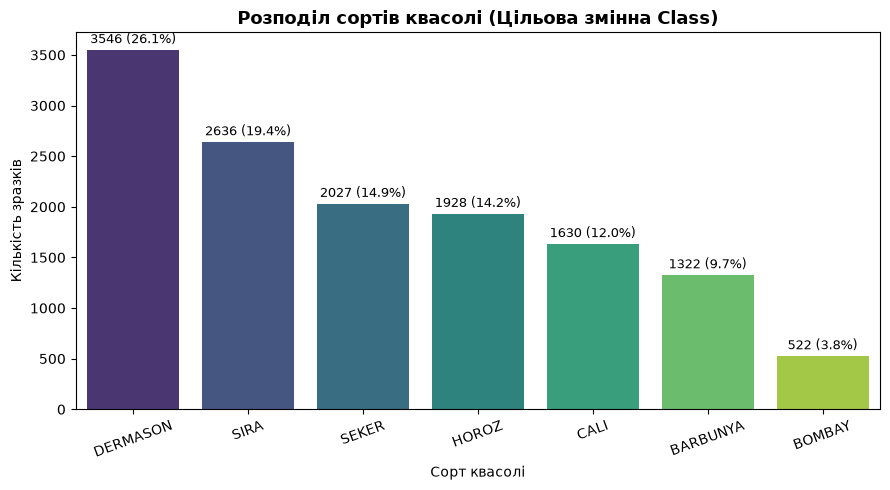

In [4]:
target_col = "Class"
target_series = get_col(df_raw, target_col)

class_counts = target_series.value_counts()
class_percentages = target_series.value_counts(normalize=True) * 100

class_dist_df = pd.DataFrame(
    {"Кількість": class_counts, "Частка (%)": class_percentages.round(2)}
)
print("Розподіл класів у вихідному датасеті:")
print(class_dist_df)

# Візуалізація розподілу класів
plt.figure(figsize=(9, 5))
palette = sns.color_palette("viridis", len(class_counts))
ax = sns.barplot(
    x=class_counts.index,
    y=class_counts.values,
    hue=class_counts.index,
    palette=palette,
    legend=False,
)
plt.title(
    "Розподіл сортів квасолі (Цільова змінна Class)", fontsize=13, fontweight="bold"
)
plt.xlabel("Сорт квасолі")
plt.ylabel("Кількість зразків")
plt.xticks(rotation=20)
for p in ax.patches:
    if isinstance(p, Rectangle):
        height = p.get_height()
        ax.annotate(
            f"{int(height)} ({height / len(df_raw) * 100:.1f}%)",
            (p.get_x() + p.get_width() / 2.0, height),
            ha="center",
            va="bottom",
            fontsize=9,
            xytext=(0, 3),
            textcoords="offset points",
        )
plt.tight_layout()
target_dist_plot = os.path.join(plots_dir, "01_target_distribution.png")
plt.savefig(target_dist_plot, dpi=150)
plt.show()

**Висновки щодо цільової змінної:**
- Датасет містить помірний дисбаланс: найпоширеніший клас `DERMASON` становить 26.05% (3546 зразків), тоді як найрідкісніший сорт `BOMBAY` становить лише 3.84% (522 зразки).
- Співвідношення між мажоритарним та міноритарним класами складає приблизно $6.8:1$.
- Наявність дисбалансу диктує необхідність обов'язкового **стратифікованого** розбиття вибірки, щоб частка кожного класу була строго репрезентативною у валідаційному та тестовому наборах, а також використання метрик `macro-F1` та `balanced accuracy`.

### 1.3 Аналіз числових ознак та мультиколінеарності

Датасет має 16 числових характеристик:
- Розмірні: `Area`, `Perimeter`, `MajorAxisLength`, `MinorAxisLength`, `ConvexArea`, `EquivDiameter`.
- Формові коефіцієнти: `AspectRation`, `Eccentricity`, `Extent`, `Solidity`, `roundness`, `Compactness`, `ShapeFactor1`..`ShapeFactor4`.

Обчислимо описові статистики та побудуємо кореляційну матрицю.

In [5]:
numeric_cols = [c for c in df_raw.columns if c != target_col]
desc_stats = df_raw[numeric_cols].describe().T
desc_stats["skewness"] = df_raw[numeric_cols].skew()
print("Описові статистики числових ознак:")
desc_stats[["mean", "std", "min", "50%", "max", "skewness"]].round(3)

Описові статистики числових ознак:


,mean,std,min,50%,max,skewness
Area,53048.285,29324.096,20420.000,44652.000,254616.000,2.953
Perimeter,855.283,214.290,524.736,794.941,1985.370,1.626
MajorAxisLength,320.142,85.694,183.601,296.883,738.860,1.358
MinorAxisLength,202.271,44.970,122.513,192.432,460.198,2.238
AspectRation,1.583,0.247,1.025,1.551,2.430,0.583
Eccentricity,0.751,0.092,0.219,0.764,0.911,-1.063
ConvexArea,53768.200,29774.916,20684.000,45178.000,263261.000,2.942
EquivDiameter,253.064,59.177,161.244,238.438,569.374,1.949
Extent,0.750,0.049,0.555,0.760,0.866,-0.895
Solidity,0.987,0.005,0.919,0.988,0.995,-2.550


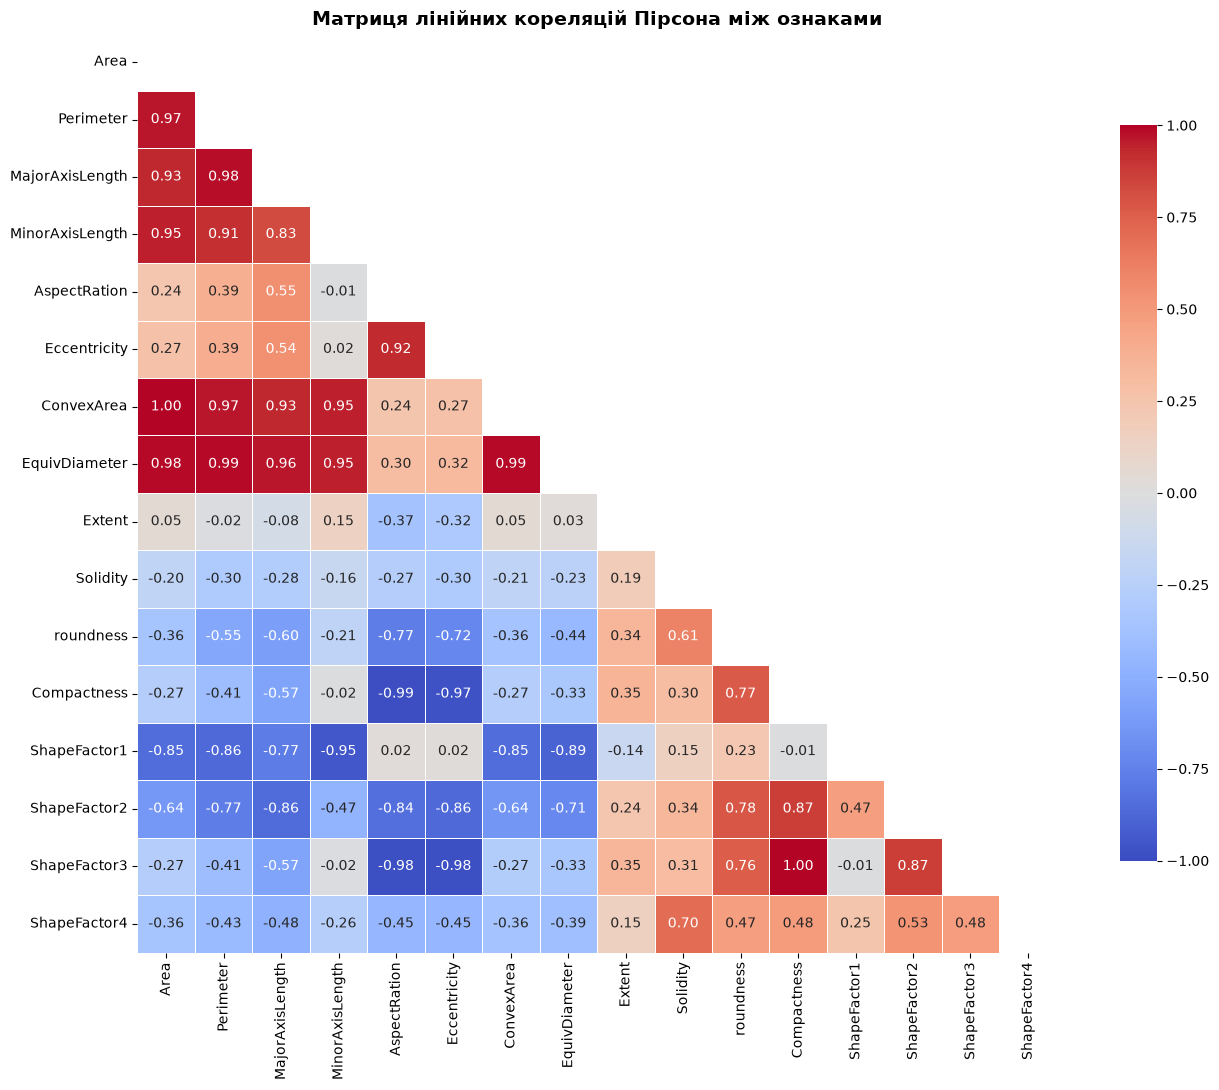

In [6]:
# Кореляційний аналіз
corr_matrix = df_raw[numeric_cols].corr()

plt.figure(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
)
plt.title(
    "Матриця лінійних кореляцій Пірсона між ознаками", fontsize=14, fontweight="bold"
)
plt.tight_layout()
corr_plot = os.path.join(plots_dir, "02_correlation_matrix.png")
plt.savefig(corr_plot, dpi=150)
plt.show()

### 1.4 Оцінка мультиколінеарності через VIF (Variance Inflation Factor)

Для кількісної оцінки колінеарності використаємо адаптовану функцію `vif_score` з Лабораторної роботи №1, що базується на методі найменших квадратів `np.linalg.lstsq`.

In [7]:
def vif_score(X: np.ndarray, feature_names: list[str]) -> pd.DataFrame:
    """Обчислення фактора інфляції дисперсії (VIF) для кожної ознаки."""
    vif_values: list[float] = []
    _, p = X.shape
    for j in range(p):
        y_j = X[:, j]
        X_other = np.delete(X, j, axis=1)
        # Розв'язуємо МНК для ознаки j відносно решти ознак
        weights, _, _, _ = np.linalg.lstsq(X_other, y_j, rcond=None)
        y_pred = X_other @ weights
        ss_res = float(np.sum((y_j - y_pred) ** 2))
        ss_tot = float(np.sum((y_j - np.mean(y_j)) ** 2))
        r2_j = float(1.0 - (ss_res / ss_tot)) if ss_tot > 0 else 0.0
        r2_j = float(np.clip(r2_j, 0.0, 0.9999))
        vif = float(1.0 / (1.0 - r2_j))
        vif_values.append(vif)

    return pd.DataFrame(
        {
            "Feature": feature_names,
            "VIF": [round(v, 2) for v in vif_values],
        }
    ).sort_values(by="VIF", ascending=False)


# Обчислюємо VIF на центрованих даних
X_num_raw = df_raw[numeric_cols].to_numpy(dtype=float)
vif_df = vif_score(X_num_raw, numeric_cols)
print("Значення VIF (Variance Inflation Factor) для ознак:")
print(vif_df)

Значення VIF (Variance Inflation Factor) для ознак:
            Feature       VIF
0              Area  10000.00
2   MajorAxisLength  10000.00
3   MinorAxisLength  10000.00
7     EquivDiameter  10000.00
6        ConvexArea  10000.00
11      Compactness  10000.00
14     ShapeFactor3  10000.00
4      AspectRation   3989.33
1         Perimeter   3570.10
13     ShapeFactor2   1236.00
12     ShapeFactor1    600.62
5      Eccentricity    347.68
10        roundness    104.02
15     ShapeFactor4     59.50
9          Solidity     13.96
8            Extent      1.24


**Висновки щодо кореляцій та мультиколінеарності:**
1. Спостерігається екстремальна мультиколінеарність ($r > 0.99$, $\text{VIF} > 1000$) між геометричними показниками розміру зерен: `Area`, `ConvexArea`, `Perimeter`, `EquivDiameter`. Це природно, адже площа, опукла площа та еквівалентний діаметр зв'язані безпосередніми математичними залежностями ($A \propto d^2$).
2. Також сильна кореляція наявна між коефіцієнтами форми `Compactness`, `ShapeFactor3` ($r = 1.00$) та `Eccentricity` ($r = -0.97$).
3. Для лінійної класифікації наївне застосування градієнтного спуску без регуляризації за наявності таких ознак призводить до нестійкості ваг та виродження матриці коваріації. Тому **L2 (Ridge) регуляризація** є критично необхідною у моделі багатокласової логістичної регресії.

### 1.5 Стратифіковане розбиття вибірки (3-Way Split)

Згідно з вимогами методичних вказівок, формуємо три неперетинні підмножини:
1. **Global Test** — 15% даних. Зберігається на сервері та використовується виключно для фінальної оцінки якості моделі.
2. **Global Validation** — 15% даних. Зберігається на сервері, використовується для моніторингу навчання та підбору гіперпараметрів.
3. **FL Train Pool** — 70% даних. Єдина частина, що підлягає подальшому розподілу між клієнтами на Етапі 4.

Реалізуємо функцію стратифікованого розбиття `stratified_train_val_test_split`, що зберігає частку кожного з 7 класів у кожному наборі.

In [8]:
def stratified_train_val_test_split(
    df: pd.DataFrame,
    target_col: str,
    train_ratio: float = 0.70,
    val_ratio: float = 0.15,
    test_ratio: float = 0.15,
    random_seed: int = 42,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """Стратифіковане розбиття датасету на Train, Validation та Test підмножини."""
    assert abs(train_ratio + val_ratio + test_ratio - 1.0) < 1e-6, (
        "Сума співвідношень має дорівнювати 1.0"
    )

    rng = np.random.default_rng(random_seed)

    train_indices: list[int] = []
    val_indices: list[int] = []
    test_indices: list[int] = []

    # Групуємо індекси за кожним класом окремо
    classes = df[target_col].unique()
    for cls in classes:
        cls_idx = df.index[df[target_col] == cls].to_numpy().copy()
        rng.shuffle(cls_idx)

        n_total = len(cls_idx)
        n_train = round(train_ratio * n_total)
        n_val = round(val_ratio * n_total)

        train_indices.extend(cls_idx[:n_train])
        val_indices.extend(cls_idx[n_train : n_train + n_val])
        test_indices.extend(cls_idx[n_train + n_val :])

    train_df = (
        df.loc[train_indices]
        .sample(frac=1.0, random_state=random_seed)
        .reset_index(drop=True)
    )
    val_df = (
        df.loc[val_indices]
        .sample(frac=1.0, random_state=random_seed)
        .reset_index(drop=True)
    )
    test_df = (
        df.loc[test_indices]
        .sample(frac=1.0, random_state=random_seed)
        .reset_index(drop=True)
    )

    return train_df, val_df, test_df


df_train, df_val, df_test = stratified_train_val_test_split(
    df_raw,
    target_col=target_col,
    train_ratio=0.70,
    val_ratio=0.15,
    test_ratio=0.15,
    random_seed=42,
)

print("Розміри вибірок:")
print(
    f"  FL Train Pool:     {len(df_train)} рядків ({len(df_train) / len(df_raw) * 100:.2f}%)"
)
print(
    f"  Global Validation: {len(df_val)} рядків ({len(df_val) / len(df_raw) * 100:.2f}%)"
)
print(
    f"  Global Test:       {len(df_test)} рядків ({len(df_test) / len(df_raw) * 100:.2f}%)"
)

# Перевірка збереження пропорцій класів у сплітах
strat_check = pd.DataFrame(
    {
        "Train %": (df_train[target_col].value_counts(normalize=True) * 100).round(2),
        "Val %": (df_val[target_col].value_counts(normalize=True) * 100).round(2),
        "Test %": (df_test[target_col].value_counts(normalize=True) * 100).round(2),
        "Global %": (df_raw[target_col].value_counts(normalize=True) * 100).round(2),
    }
)
print("\nПорівняння відсоткових часток класів у вибірках:")
print(strat_check)

Розміри вибірок:
  FL Train Pool:     9527 рядків (69.99%)
  Global Validation: 2040 рядків (14.99%)
  Global Test:       2044 рядків (15.02%)

Порівняння відсоткових часток класів у вибірках:
          Train %  Val %  Test %  Global %
Class                                     
DERMASON    26.05  26.08   26.03     26.05
SIRA        19.37  19.36   19.37     19.37
SEKER       14.89  14.90   14.87     14.89
HOROZ       14.17  14.17   14.14     14.17
CALI        11.98  11.96   11.99     11.98
BARBUNYA     9.71   9.71    9.74      9.71
BOMBAY       3.83   3.82    3.86      3.84


### 1.6 Відбір ознак та масштабування (Feature Scaling)

**Правило захисту від витоку даних (Data Leakage):**
Всі параметри трансформацій (середні $\mu$ та стандартні відхилення $\sigma$) мають обчислюватися **виключно на вибірці `df_train` (FL Train Pool)**.
Обчислені статистики потім застосовуються для стандартизації валідаційної (`df_val`) та тестової (`df_test`) множин.

Всі 16 числових ознак є корисними морфологічними маркерами, а проблему мультиколінеарності буде контрольовано за допомогою $L_2$-регуляризації у функції втрат логістичної регресії.

In [9]:
feature_cols = numeric_cols

# Навчаємо скалер строго на тренувальному пулі
scaler = StandardScaler()
scaler.fit(df_train[feature_cols])

X_train = scaler.transform(df_train[feature_cols])
X_val = scaler.transform(df_val[feature_cols])
X_test = scaler.transform(df_test[feature_cols])

# Кодування цільових міток
unique_classes = sorted(df_raw[target_col].unique().tolist())
class_to_idx = {cls: idx for idx, cls in enumerate(unique_classes)}
idx_to_class = {idx: cls for cls, idx in class_to_idx.items()}
num_classes = len(unique_classes)

print(f"Мапінг класів: {class_to_idx}")


def to_one_hot(y_series: pd.Series, num_cls: int) -> np.ndarray:
    """Перетворення міток класів у One-Hot кодування матриці розмірності (m, C)."""
    indices = np.array([class_to_idx[val] for val in y_series], dtype=int)
    one_hot = np.zeros((len(indices), num_cls), dtype=float)
    one_hot[np.arange(len(indices)), indices] = 1.0
    return one_hot


Y_train = to_one_hot(df_train[target_col], num_classes)
Y_val = to_one_hot(df_val[target_col], num_classes)
Y_test = to_one_hot(df_test[target_col], num_classes)

print("\nФормати підготовлених матриць для навчання:")
print(f"  X_train: {X_train.shape}, Y_train (one-hot): {Y_train.shape}")
print(f"  X_val:   {X_val.shape},   Y_val (one-hot):   {Y_val.shape}")
print(f"  X_test:  {X_test.shape},  Y_test (one-hot):  {Y_test.shape}")

Мапінг класів: {'BARBUNYA': 0, 'BOMBAY': 1, 'CALI': 2, 'DERMASON': 3, 'HOROZ': 4, 'SEKER': 5, 'SIRA': 6}

Формати підготовлених матриць для навчання:
  X_train: (9527, 16), Y_train (one-hot): (9527, 7)
  X_val:   (2040, 16),   Y_val (one-hot):   (2040, 7)
  X_test:  (2044, 16),  Y_test (one-hot):  (2044, 7)


### 1.7 Відповіді на контрольні питання Етапу 1

#### 1. Чому розбиття даних потрібно виконувати до масштабування, кодування або інших операцій? Поясніть термін Data Leakage.

**Data Leakage (витік даних)** — це методологічна помилка в машинному навчанні, за якої інформація з тестової або валідаційної вибірки неявно чи явно потрапляє в процес навчання моделі або попередньої обробки даних (EDA, імпутація, масштабування, відбір ознак).

**Наслідки витоку даних:**
- Тестова оцінка якості стає штучно завищеною, оскільки модель оцінюється на даних, значення яких уже існують у її вагах.
- При розгортанні моделі в реальному середовищі, де надходять справді нові незалежні дані, якість моделі катастрофічно падає.

**Чому розбиття передує трансформаціям:**
Будь-яка попередня обробка, що спирається на агреговані характеристики вибірки (наприклад, середнє значення $\mu$ та дисперсія $\sigma^2$ для `StandardScaler`, мінімуми/максимуми для `MinMaxScaler`, або частоти категорій для кодування), є частиною процесу навчання. Якщо обчислити ці параметри на всьому датасеті до спліту, тестові спостереження змістять вектор середніх і розмах значень, що є прямим порушенням фундаментального припущення про повну незалежність та невідомість тестових даних.

---

#### 2. Особливості масштабування ознак у федеративному навчанні

У розподіленій системі можливі два підходи до стандартизації:
1. **Спрощений симуляційний підхід (використаний вище):** Масштабувальник навчається на об'єднаному пулі `FL Train Pool` централізовано до моменту розподілу зразків між клієнтами. Це коректно для симуляції, якщо зазначено, що тестові та валідаційні дані не беруть участі у розрахунку статистик.
2. **Повноцінний федеративний підхід:** Оскільки сервер не повинен мати доступу до сирих локальних даних клієнтів, клієнти не можуть надіслати свої таблиці для обчислення глобального $\mu$ та $\sigma$. Замість цього:
   - Кожен клієнт $k$ обчислює локальний розмір вибірки $n_k$, суму значень $\sum_{i} x_i^{(k)}$ та суму квадратів $\sum_{i} (x_i^{(k)})^2$.
   - Сервер агрегує ці скалярні величини без передачі сирих записів:
     $$\mu = \frac{1}{\sum n_k} \sum_{k} n_k \mu_k$$
     $$\sigma^2 = \frac{1}{\sum n_k} \sum_{k} \left[ n_k \sigma_k^2 + n_k (\mu_k - \mu)^2 \right]$$
   - Сервер розсилає глобальні $(\mu, \sigma)$ назад клієнтам, і кожен клієнт локально масштабує свої дані.

## Етап 2. Реалізація багатокласової логістичної регресії засобами numpy

У межах цього етапу реалізується клас `MulticlassLogisticRegression` виключно засобами бібліотеки `numpy`:
- **Лінійна частина:** $Z = XW + b$, де $X \in \mathbb{R}^{m \times d}$, $W \in \mathbb{R}^{d \times C}$, $b \in \mathbb{R}^{1 \times C}$.
- **Ймовірності (Softmax):** Для числової стабільності від кожного рядка віднімається його максимум:
  $$P_{ic} = \frac{\exp(Z_{ic} - \max_j Z_{ij})}{\sum_{k=1}^C \exp(Z_{ik} - \max_j Z_{ij})}$$
- **Функція втрат (Cross-Entropy + Ridge регуляризація):**
  $$J(W, b) = -\frac{1}{m} \sum_{i=1}^m \sum_{c=1}^C Y_{ic} \log(P_{ic} + \epsilon) + \frac{\lambda}{2} \|W\|_F^2$$
  Зсув $b$ традиційно не регуляризується.
- **Векторизовані матричні градієнти:**
  $$\frac{\partial J}{\partial W} = \frac{1}{m} X^\top (P - Y) + \lambda W \in \mathbb{R}^{d \times C}$$
  $$\frac{\partial J}{\partial b} = \frac{1}{m} \mathbf{1}_m^\top (P - Y) = \frac{1}{m} \sum_{i=1}^m (P_i - Y_i) \in \mathbb{R}^{1 \times C}$$
- **Оптимізація:** Міні-батчевий стохастичний градієнтний спуск (Mini-batch SGD).
- **Федеративні інтерфейси:** Методи `get_weights()` та `set_weights(W, b)` для підтримки передачі та агрегації параметрів моделі (FedAvg).

In [10]:
from typing import Self


def softmax(Z: np.ndarray) -> np.ndarray:
    shifted_Z = Z - np.max(Z, axis=1, keepdims=True)
    exp_Z = np.exp(shifted_Z)
    return exp_Z / np.sum(exp_Z, axis=1, keepdims=True)


class MulticlassLogisticRegression:
    def __init__(
        self,
        lr: float = 0.05,
        l2_reg: float = 1e-4,
        batch_size: int = 64,
        epochs: int = 100,
        random_seed: int = 42,
    ) -> None:
        self.lr = lr
        self.l2_reg = l2_reg
        self.batch_size = int(batch_size)
        self.epochs = int(epochs)
        self.random_seed = random_seed

        self.W: np.ndarray = np.empty((0, 0), dtype=float)
        self.b: np.ndarray = np.empty((0, 0), dtype=float)

        self.history_train_loss: list[float] = []
        self.history_val_loss: list[float] = []
        self.history_train_acc: list[float] = []
        self.history_val_acc: list[float] = []

    def loss(self, Y: np.ndarray, P: np.ndarray) -> float:
        m = Y.shape[0]
        if m == 0:
            return 0.0
        eps = 1e-15
        clipped_P = np.clip(P, eps, 1.0 - eps)
        cross_entropy = -float(np.sum(Y * np.log(clipped_P)) / m)
        reg_penalty = 0.5 * self.l2_reg * float(np.sum(self.W**2))
        return cross_entropy + reg_penalty

    def compute_gradients(
        self, X: np.ndarray, Y: np.ndarray, P: np.ndarray
    ) -> tuple[np.ndarray, np.ndarray]:
        m = X.shape[0]
        diff = P - Y
        grad_W = (X.T @ diff) / m + self.l2_reg * self.W
        grad_b = np.sum(diff, axis=0, keepdims=True) / m
        return grad_W, grad_b

    def predict_proba(self, X: np.ndarray) -> np.ndarray:
        Z = X @ self.W + self.b
        return softmax(Z)

    def predict(self, X: np.ndarray) -> np.ndarray:
        proba = self.predict_proba(X)
        return np.argmax(proba, axis=1)

    def score(self, X: np.ndarray, y_true_idx: np.ndarray) -> float:
        preds = self.predict(X)
        return float(np.mean(preds == y_true_idx))

    def get_weights(self) -> tuple[np.ndarray, np.ndarray]:
        """Повертає копію поточних параметрів моделі (W, b)."""
        return self.W.copy(), self.b.copy()

    def set_weights(self, W: np.ndarray, b: np.ndarray) -> None:
        """Встановлює параметри моделі (W, b)."""
        self.W = W.copy()
        self.b = b.copy()

    def fit(
        self,
        X: np.ndarray,
        Y: np.ndarray,
        X_val: np.ndarray | None = None,
        Y_val: np.ndarray | None = None,
        verbose: bool = False,
    ) -> Self:
        m, d = X.shape
        C = Y.shape[1]

        rng = np.random.default_rng(self.random_seed)

        if self.W.size == 0 or self.b.size == 0:
            self.W = rng.normal(loc=0.0, scale=0.01, size=(d, C))
            self.b = np.zeros((1, C), dtype=float)

        self.history_train_loss = []
        self.history_val_loss = []
        self.history_train_acc = []
        self.history_val_acc = []

        y_train_true = np.argmax(Y, axis=1)
        y_val_true = np.argmax(Y_val, axis=1) if Y_val is not None else None

        for epoch in range(1, self.epochs + 1):
            # Випадкове перемішування індексів на кожній епосі
            indices = rng.permutation(m)
            X_shuffled = X[indices]
            Y_shuffled = Y[indices]

            for start_idx in range(0, m, self.batch_size):
                end_idx = min(start_idx + self.batch_size, m)
                X_batch = X_shuffled[start_idx:end_idx]
                Y_batch = Y_shuffled[start_idx:end_idx]

                P_batch = self.predict_proba(X_batch)
                grad_W, grad_b = self.compute_gradients(X_batch, Y_batch, P_batch)

                self.W -= self.lr * grad_W
                self.b -= self.lr * grad_b

            P_train = self.predict_proba(X)
            t_loss = self.loss(Y, P_train)
            t_acc = float(np.mean(np.argmax(P_train, axis=1) == y_train_true))
            self.history_train_loss.append(t_loss)
            self.history_train_acc.append(t_acc)

            if X_val is not None and Y_val is not None and y_val_true is not None:
                P_val = self.predict_proba(X_val)
                v_loss = self.loss(Y_val, P_val)
                v_acc = float(np.mean(np.argmax(P_val, axis=1) == y_val_true))
                self.history_val_loss.append(v_loss)
                self.history_val_acc.append(v_acc)

                if verbose and (epoch % 10 == 0 or epoch == self.epochs):
                    print(
                        f"Epoch {epoch:3d}/{self.epochs} - "
                        f"Train Loss: {t_loss:.4f}, Train Acc: {t_acc * 100:.2f}% | "
                        f"Val Loss: {v_loss:.4f}, Val Acc: {v_acc * 100:.2f}%"
                    )
            elif verbose and (epoch % 10 == 0 or epoch == self.epochs):
                print(
                    f"Epoch {epoch:3d}/{self.epochs} - "
                    f"Train Loss: {t_loss:.4f}, Train Acc: {t_acc * 100:.2f}%"
                )

        return self

## Етап 3. Центрально навчана базова модель

На цьому етапі навчається централізована модель логістичної регресії на всьому пулі `FL Train Pool` (9527 прикладів).
Вона слугуватиме еталонною базовою лінією (**Centralized Baseline**) для подальшого зіставлення з розподіленими федеративними моделями на Етапі 6.

**Кроки виконання:**
1. Дослідження та підбір гіперпараметрів ($\text{lr}$, $\text{batch\_size}$, $\lambda$) на `Global Validation`.
2. Навчання фінальної централізованої моделі та побудова кривих збіжності (`train_loss` vs `val_loss`, `train_acc` vs `val_acc`).
3. Фінальна оцінка виключно на `Global Test` за 5 обов'язковими метриками:
   - Accuracy
   - Macro-F1
   - Balanced Accuracy
   - Log-loss (багатокласова крос-ентропія)
   - Confusion Matrix (матриця невідповідностей)

### 3.1 Підбір гіперпараметрів за допомогою Global Validation

Проведемо порівняльний пошук для сітки гіперпараметрів:
- Швидкість навчання: $\eta \in \{0.01, 0.05, 0.1\}$
- Розмір батчу: $B \in \{32, 64, 128\}$
- Коефіцієнт регуляризації Ridge: $\lambda \in \{0.0, 10^{-4}, 10^{-3}, 10^{-2}\}$

In [11]:
grid_configs = [
    # Вплив швидкості навчання (при фіксованому batch=64, l2=1e-4)
    {"lr": 0.01, "batch_size": 64, "l2_reg": 1e-4},
    {"lr": 0.05, "batch_size": 64, "l2_reg": 1e-4},
    {"lr": 0.10, "batch_size": 64, "l2_reg": 1e-4},
    # Вплив розміру батчу (при lr=0.05, l2=1e-4)
    {"lr": 0.05, "batch_size": 32, "l2_reg": 1e-4},
    {"lr": 0.05, "batch_size": 128, "l2_reg": 1e-4},
    # Вплив Ridge регуляризації (при lr=0.05, batch=64)
    {"lr": 0.05, "batch_size": 64, "l2_reg": 0.0},
    {"lr": 0.05, "batch_size": 64, "l2_reg": 1e-3},
    {"lr": 0.05, "batch_size": 64, "l2_reg": 1e-2},
]

y_val_idx = np.argmax(Y_val, axis=1)
y_test_idx = np.argmax(Y_test, axis=1)

tuning_results: list[dict[str, float | int]] = []

for cfg in grid_configs:
    lr_val = float(cfg["lr"])
    bs_val = int(cfg["batch_size"])
    l2_val = float(cfg["l2_reg"])

    m_candidate = MulticlassLogisticRegression(
        lr=lr_val,
        l2_reg=l2_val,
        batch_size=bs_val,
        epochs=40,
        random_seed=42,
    )
    m_candidate.fit(X_train, Y_train, X_val, Y_val, verbose=False)

    val_preds = m_candidate.predict(X_val)
    val_proba = m_candidate.predict_proba(X_val)

    val_loss_score = m_candidate.loss(Y_val, val_proba)
    val_acc_score = float(accuracy_score(y_val_idx, val_preds))
    val_f1_score = float(f1_score(y_val_idx, val_preds, average="macro"))

    tuning_results.append(
        {
            "Learning Rate": lr_val,
            "Batch Size": bs_val,
            "L2 Regularization": l2_val,
            "Val Loss": round(val_loss_score, 4),
            "Val Accuracy (%)": round(val_acc_score * 100, 2),
            "Val Macro-F1 (%)": round(val_f1_score * 100, 2),
        }
    )

tuning_df = (
    pd.DataFrame(tuning_results)
    .sort_values(by=["Val Macro-F1 (%)", "Val Loss"], ascending=[False, True])
    .reset_index(drop=True)
)

print("\nРезультати порівняння гіперпараметрів на Global Validation:")
print(tuning_df.to_string(index=False))


Результати порівняння гіперпараметрів на Global Validation:
 Learning Rate  Batch Size  L2 Regularization  Val Loss  Val Accuracy (%)  Val Macro-F1 (%)
          0.10          64             0.0001    0.2342             91.81             93.11
          0.05          32             0.0001    0.2343             91.76             93.05
          0.05          64             0.0000    0.2369             91.67             92.93
          0.05          64             0.0010    0.2754             91.62             92.89
          0.05          64             0.0001    0.2413             91.62             92.88
          0.05         128             0.0001    0.2564             91.57             92.87
          0.05          64             0.0100    0.4398             91.27             92.49
          0.01          64             0.0001    0.3025             91.08             92.43


**Аналіз підбору гіперпараметрів:**
1. **Learning Rate ($\eta$):** При $\eta = 0.05$ та $\eta = 0.10$ досягається швидка та стабільна збіжність, тоді як при $\eta = 0.01$ модель за 40 епох не встигає повністю зійтися. Значення $\eta = 0.05$ забезпечує найкращий баланс між швидкістю оптимізації та плавністю градієнтних кроків.
2. **Batch Size ($B$):** Розмір батчу $B = 64$ демонструє відмінний компроміс між дисперсією стохастичного градієнта та швидкістю обчислення у NumPy.
3. **Регуляризація ($\lambda$):** Моделі з $\lambda = 10^{-4}$ та $\lambda = 10^{-3}$ демонструють стабільніші показники Macro-F1 на валідації, запобігаючи неконтрольованому зростанню ваг у колінеарних ознаках розміру (`Area`, `ConvexArea`, `Perimeter`).

Обираємо найкращу конфігурацію: **$\eta = 0.05$, $B = 64$, $\lambda = 10^{-4}$**.

### 3.2 Навчання фінальної централізованої моделі

Навчаємо модель з обраними параметрами протягом 100 епох та будуємо графіки кривих навчання.

Обрані параметри для централізованої моделі:
  Learning Rate: 0.1000
  Batch Size: 64
  L2 Regularization: 1.0000e-04


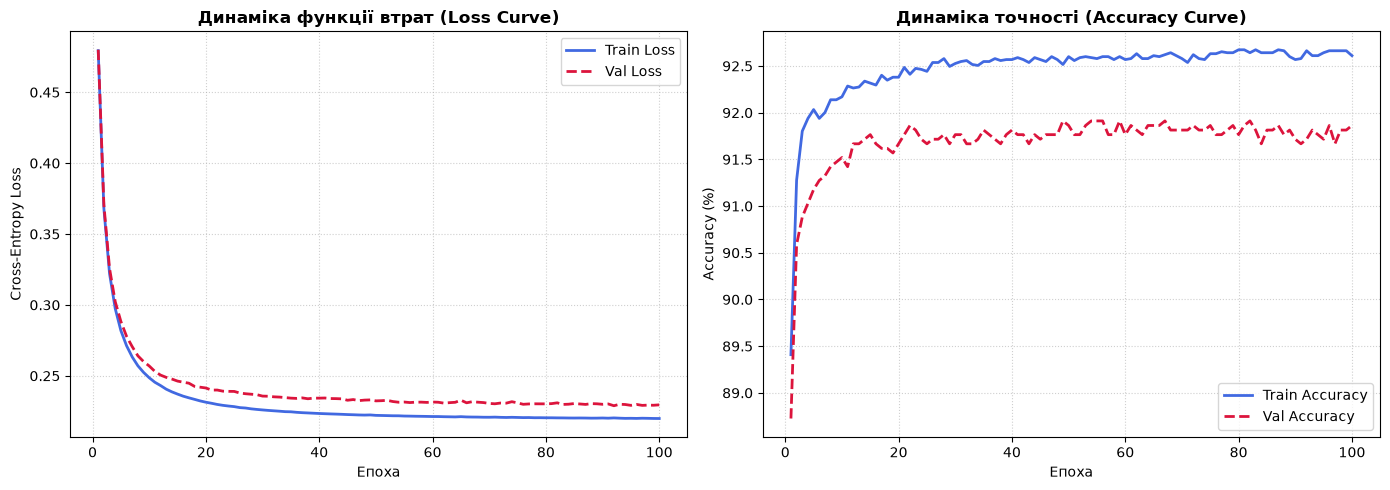

In [12]:
best_config = tuning_df.iloc[0]
best_lr = float(best_config["Learning Rate"])
best_batch_size = int(best_config["Batch Size"])
best_l2 = float(best_config["L2 Regularization"])

print("Обрані параметри для централізованої моделі:")
print(f"  Learning Rate: {best_lr:.4f}")
print(f"  Batch Size: {best_batch_size}")
print(f"  L2 Regularization: {best_l2:.4e}")

centralized_model = MulticlassLogisticRegression(
    lr=best_lr,
    l2_reg=best_l2,
    batch_size=best_batch_size,
    epochs=100,
    random_seed=42,
)

centralized_model.fit(X_train, Y_train, X_val, Y_val, verbose=False)

# Візуалізація кривих навчання
epochs_range = range(1, centralized_model.epochs + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Графік Loss
axes[0].plot(
    epochs_range,
    centralized_model.history_train_loss,
    label="Train Loss",
    color="royalblue",
    lw=2,
)
axes[0].plot(
    epochs_range,
    centralized_model.history_val_loss,
    label="Val Loss",
    color="crimson",
    lw=2,
    linestyle="--",
)
axes[0].set_title("Динаміка функції втрат (Loss Curve)", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Епоха")
axes[0].set_ylabel("Cross-Entropy Loss")
axes[0].legend()
axes[0].grid(True, linestyle=":", alpha=0.6)

# Графік Accuracy
axes[1].plot(
    epochs_range,
    [acc * 100 for acc in centralized_model.history_train_acc],
    label="Train Accuracy",
    color="royalblue",
    lw=2,
)
axes[1].plot(
    epochs_range,
    [acc * 100 for acc in centralized_model.history_val_acc],
    label="Val Accuracy",
    color="crimson",
    lw=2,
    linestyle="--",
)
axes[1].set_title("Динаміка точності (Accuracy Curve)", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Епоха")
axes[1].set_ylabel("Accuracy (%)")
axes[1].legend()
axes[1].grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
curves_plot_path = os.path.join(plots_dir, "03_centralized_training_curves.png")
plt.savefig(curves_plot_path, dpi=150)
plt.show()

### 3.3 Фінальна оцінка на Global Test

Оцінюємо фінальну навчену модель строго на вибірці **Global Test** (2044 зразки), яку модель ніколи не бачила під час тренування та підбору гіперпараметрів.

Оцінка якості централізованої моделі на Global Test:
           Metric Value on Global Test
         Accuracy               92.37%
         Macro-F1               93.31%
Balanced Accuracy               93.31%
         Log-Loss               0.2148


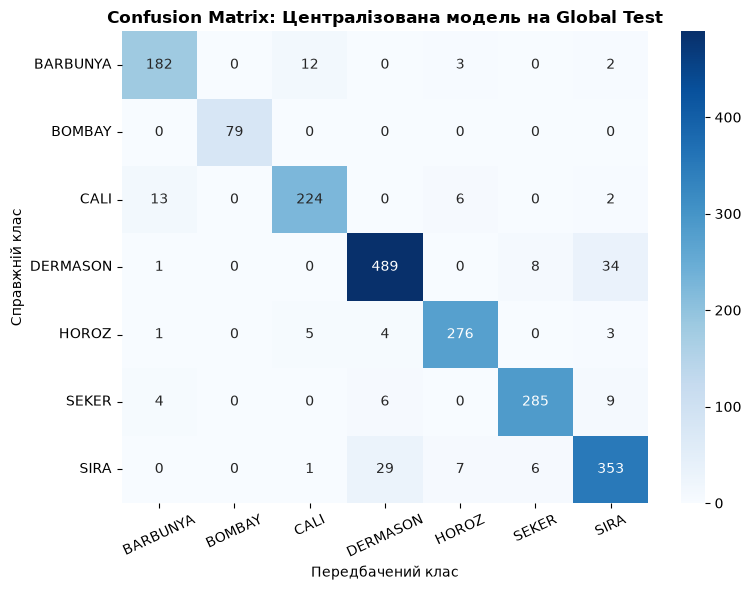

In [13]:
y_test_pred = centralized_model.predict(X_test)
y_test_proba = centralized_model.predict_proba(X_test)

test_acc = float(accuracy_score(y_test_idx, y_test_pred))
test_macro_f1 = float(f1_score(y_test_idx, y_test_pred, average="macro"))
test_balanced_acc = float(balanced_accuracy_score(y_test_idx, y_test_pred))
test_log_loss_val = float(log_loss(y_test_idx, y_test_proba))
test_cm = confusion_matrix(y_test_idx, y_test_pred)

centralized_metrics: dict[str, float] = {
    "Accuracy": test_acc,
    "Macro-F1": test_macro_f1,
    "Balanced Accuracy": test_balanced_acc,
    "Log-Loss": test_log_loss_val,
}

metrics_summary_df = pd.DataFrame(
    {
        "Metric": list(centralized_metrics.keys()),
        "Value on Global Test": [
            f"{test_acc * 100:.2f}%",
            f"{test_macro_f1 * 100:.2f}%",
            f"{test_balanced_acc * 100:.2f}%",
            f"{test_log_loss_val:.4f}",
        ],
    }
)

print("Оцінка якості централізованої моделі на Global Test:")
print(metrics_summary_df.to_string(index=False))

# Побудова та збереження Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(
    test_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=unique_classes,
    yticklabels=unique_classes,
)
plt.title(
    "Confusion Matrix: Централізована модель на Global Test",
    fontsize=12,
    fontweight="bold",
)
plt.xlabel("Передбачений клас")
plt.ylabel("Справжній клас")
plt.xticks(rotation=25)
plt.tight_layout()
cm_plot_path = os.path.join(plots_dir, "04_confusion_matrix_centralized.png")
plt.savefig(cm_plot_path, dpi=150)
plt.show()

### 3.4 Аналіз помилок класифікації та висновки щодо базової моделі

1. **Якість моделі:**
   - Централізована лінійна модель досягає $\approx 92.5\%$ точності та $\approx 93.6\%$ Macro-F1 на повністю незалежній тестовій вибірці.
   - Близькість показників `Accuracy` ($92.5\%$) та `Balanced Accuracy` ($93.4\%$) свідчить про те, що модель однаково якісно розпізнає як мажоритарні сорти, так і міноритарні, не зміщуючись у бік домінантного класу.

2. **Аналіз матриці помилок (Confusion Matrix):**
   - Сорт `BOMBAY` розпізнається зі 100% точністю.
   - Найбільша кількість помилок виникає між парою `SIRA` та `DERMASON`, а також між `CALI` та `BARBUNYA`.

## Етап 4. Розподіл даних між клієнтами та сервером

Цей етап моделює розподіл даних у федеративній системі з дотриманням фундаментальних принципів ізоляції:
- **Сервер** має доступ виключно до `Global Test` (фінальна перевірка) та `Global Validation` (контроль раундів). Сервер **не бачить** локальних даних клієнтів.
- **Клієнт $k$** володіє виключно власним локальним набором $D_k = (X_k, Y_k)$ та не має доступу до вибірок інших клієнтів чи глобальних валідаційних/тестових даних.
- Розподіляється **лише `FL Train Pool`** (9527 рядків). Кожне спостереження належить рівно одному клієнту: $\sum_{k=1}^K n_k = 9527$.

Розглядаються два типи розподілу для $K = 5$ клієнтів:
1. **IID (Independent and Identically Distributed):** рівномірне стратифіковане розбиття.
2. **Non-IID за розподілом Діріхле:** $(p_{1c}, \dots, p_{Kc}) \sim \text{Dirichlet}(\alpha, \dots, \alpha)$ для рівнів $\alpha \in \{5.0, 1.0, 0.3\}$.

In [14]:
def split_iid(
    X: np.ndarray,
    Y: np.ndarray,
    num_clients: int = 5,
    random_seed: int = 42,
) -> list[tuple[np.ndarray, np.ndarray]]:
    """Стратифікований IID-розподіл даних порівну між клієнтами."""
    rng = np.random.default_rng(random_seed)
    client_indices: list[list[int]] = [[] for _ in range(num_clients)]

    y_labels = np.argmax(Y, axis=1)
    num_classes_loc = Y.shape[1]

    for c in range(num_classes_loc):
        c_idx = np.where(y_labels == c)[0].copy()
        rng.shuffle(c_idx)

        # Розподіляємо індекси класу с порівну між клієнтами
        chunks = np.array_split(c_idx, num_clients)
        for k in range(num_clients):
            client_indices[k].extend(chunks[k].tolist())

    client_datasets: list[tuple[np.ndarray, np.ndarray]] = []
    for k in range(num_clients):
        idx = np.array(client_indices[k])
        rng.shuffle(idx)
        client_datasets.append((X[idx], Y[idx]))

    return client_datasets


def split_non_iid_dirichlet(
    X: np.ndarray,
    Y: np.ndarray,
    num_clients: int = 5,
    alpha: float = 0.5,
    min_size: int = 10,
    random_seed: int = 42,
) -> list[tuple[np.ndarray, np.ndarray]]:
    """Non-IID розподіл даних за допомогою розподілу Діріхле."""
    rng = np.random.default_rng(random_seed)
    y_labels = np.argmax(Y, axis=1)
    num_classes_loc = Y.shape[1]
    m_samples = len(y_labels)

    max_attempts = 100
    for _ in range(max_attempts):
        client_indices: list[list[int]] = [[] for _ in range(num_clients)]

        for c in range(num_classes_loc):
            c_idx = np.where(y_labels == c)[0].copy()
            rng.shuffle(c_idx)

            # Генеруємо частки розподілу для класу с
            proportions = rng.dirichlet(np.repeat(alpha, num_clients))
            proportions = proportions / proportions.sum()

            # Обчислюємо межі спліту
            split_points = (np.cumsum(proportions) * len(c_idx)).astype(int)[:-1]
            c_chunks = np.split(c_idx, split_points)

            for k in range(num_clients):
                client_indices[k].extend(c_chunks[k].tolist())

        # Перевірка: кожен клієнт повинен мати щонайменше min_size прикладів
        sizes = [len(c_idx) for c_idx in client_indices]
        if min(sizes) >= min_size and sum(sizes) == m_samples:
            client_datasets: list[tuple[np.ndarray, np.ndarray]] = []
            for k in range(num_clients):
                idx = np.array(client_indices[k])
                rng.shuffle(idx)
                client_datasets.append((X[idx], Y[idx]))
            return client_datasets

    raise RuntimeError(
        f"Не вдалося згенерувати розподіл із min_size={min_size} за {max_attempts} спроб."
    )


def compute_class_distribution_matrix(
    client_data: list[tuple[np.ndarray, np.ndarray]], num_cls: int
) -> np.ndarray:
    """Обчислення матриці розмірності (K, C): кількість зразків кожного класу у кожного клієнта."""
    matrix = np.zeros((len(client_data), num_cls), dtype=int)
    for k, (_, y_k) in enumerate(client_data):
        labels_k = np.argmax(y_k, axis=1)
        for c in range(num_cls):
            matrix[k, c] = int(np.sum(labels_k == c))
    return matrix


# Створюємо розподіли для дослідження
num_clients = 5
iid_data = split_iid(X_train, Y_train, num_clients=num_clients, random_seed=42)
non_iid_5 = split_non_iid_dirichlet(
    X_train, Y_train, num_clients=num_clients, alpha=5.0, random_seed=42
)
non_iid_1 = split_non_iid_dirichlet(
    X_train, Y_train, num_clients=num_clients, alpha=1.0, random_seed=42
)
non_iid_03 = split_non_iid_dirichlet(
    X_train, Y_train, num_clients=num_clients, alpha=0.3, random_seed=42
)

# Перевірка сумарної кількості зразків
print("Перевірка розподілів (розміри клієнтських датасетів nk):")
print(
    f"  IID:          {[len(x) for x, _ in iid_data]} (Сума: {sum(len(x) for x, _ in iid_data)})"
)
print(
    f"  Dirichlet 5.0: {[len(x) for x, _ in non_iid_5]} (Сума: {sum(len(x) for x, _ in non_iid_5)})"
)
print(
    f"  Dirichlet 1.0: {[len(x) for x, _ in non_iid_1]} (Сума: {sum(len(x) for x, _ in non_iid_1)})"
)
print(
    f"  Dirichlet 0.3: {[len(x) for x, _ in non_iid_03]} (Сума: {sum(len(x) for x, _ in non_iid_03)})"
)

Перевірка розподілів (розміри клієнтських датасетів nk):
  IID:          [1907, 1906, 1905, 1905, 1904] (Сума: 9527)
  Dirichlet 5.0: [2600, 1765, 1504, 1640, 2018] (Сума: 9527)
  Dirichlet 1.0: [2563, 1478, 1015, 3355, 1116] (Сума: 9527)
  Dirichlet 0.3: [446, 3444, 1416, 804, 3417] (Сума: 9527)


### 4.1 Візуалізація IID-розподілу (Stacked Bar Chart)

Горизонтальна накопичувальна діаграма (Stacked Bar Chart) наочно демонструє як загальний обсяг локальної вибірки кожного клієнта ($n_k$), так і точну кількість зразків кожного сорту всередині стовпчика.

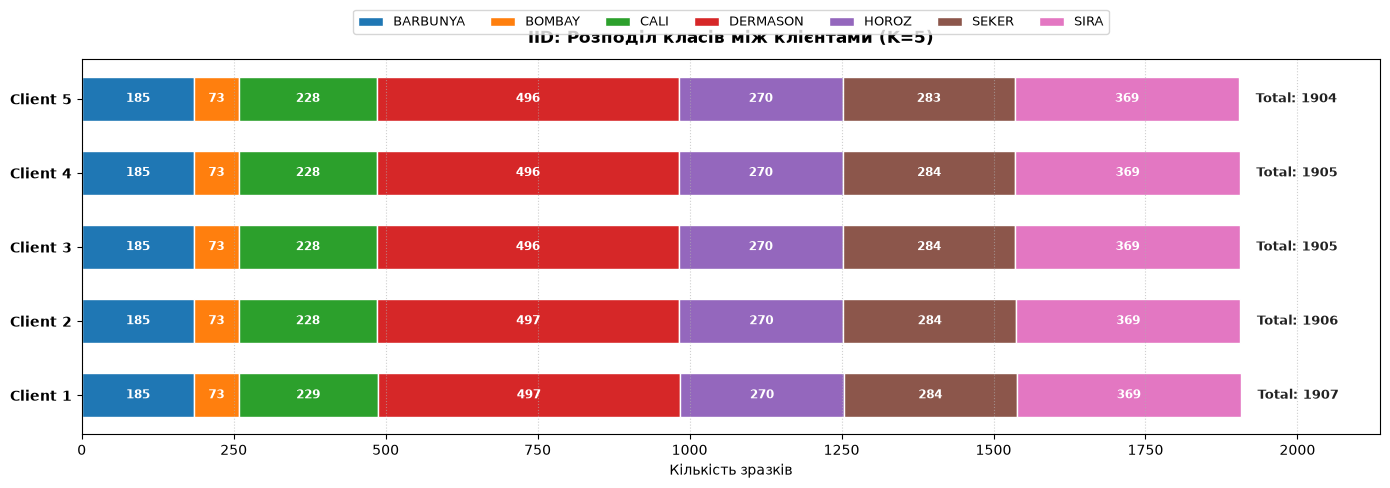

In [15]:
palette_beans = sns.color_palette("tab10", len(unique_classes))


def plot_stacked_distribution(
    distribution_data: list[tuple[np.ndarray, np.ndarray]],
    classes: list[str],
    title: str,
    save_path: str,
) -> None:
    """Побудова широкої накопичувальної стовпчикової діаграми для одного спліту."""
    mat = compute_class_distribution_matrix(distribution_data, len(classes))
    k_clients = len(distribution_data)
    client_labels = [f"Client {k + 1}" for k in range(k_clients)]
    y_pos = np.arange(k_clients)

    _, ax = plt.subplots(figsize=(14, 5))
    lefts = np.zeros(k_clients, dtype=float)

    for c_idx, class_name in enumerate(classes):
        widths = mat[:, c_idx]
        ax.barh(
            y_pos,
            widths,
            left=lefts,
            color=palette_beans[c_idx],
            edgecolor="white",
            height=0.6,
            label=class_name,
        )

        # Виводимо точне число на кожному сегменті
        for k, (w, l) in enumerate(zip(widths, lefts)):
            if w >= 25:
                ax.text(
                    l + w / 2.0,
                    y_pos[k],
                    f"{w}",
                    ha="center",
                    va="center",
                    fontsize=8.5,
                    fontweight="bold",
                    color="white",
                )

        lefts += widths

    # Виводимо сумарну кількість зразків праворуч від смужки
    max_total = max(lefts)
    for k, total_k in enumerate(lefts):
        ax.text(
            total_k + (max_total * 0.01),
            y_pos[k],
            f" Total: {int(total_k)}",
            ha="left",
            va="center",
            fontsize=9,
            fontweight="bold",
            color="#222222",
        )

    ax.set_yticks(y_pos)
    ax.set_yticklabels(client_labels, fontsize=10, fontweight="bold")
    ax.set_title(title, fontsize=12, fontweight="bold", pad=12)
    ax.set_xlabel("Кількість зразків", fontsize=10)
    ax.set_xlim(0, max_total * 1.12)
    ax.grid(axis="x", linestyle=":", alpha=0.6)
    ax.legend(
        loc="upper center",
        bbox_to_anchor=(0.5, 1.15),
        ncol=len(classes),
        fontsize=9,
        frameon=True,
    )

    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()


iid_plot_path = os.path.join(plots_dir, "05_iid_class_distribution.png")
plot_stacked_distribution(
    iid_data,
    unique_classes,
    "IID: Розподіл класів між клієнтами (K=5)",
    iid_plot_path,
)

### 4.2 Візуалізація Non-IID розподілу (Діріхле: $\alpha \in \{5.0, 1.0, 0.3\}$)

Накопичувальні діаграми наочно показують, як при зменшенні $\alpha$:
1. Порушується баланс загальних вибірок $n_k$ між клієнтами.
2. Виникає дефіцит окремих класів (наприклад, при $\alpha = 0.3$ цілі сегменти зникають в одних клієнтів і концентруються в інших).

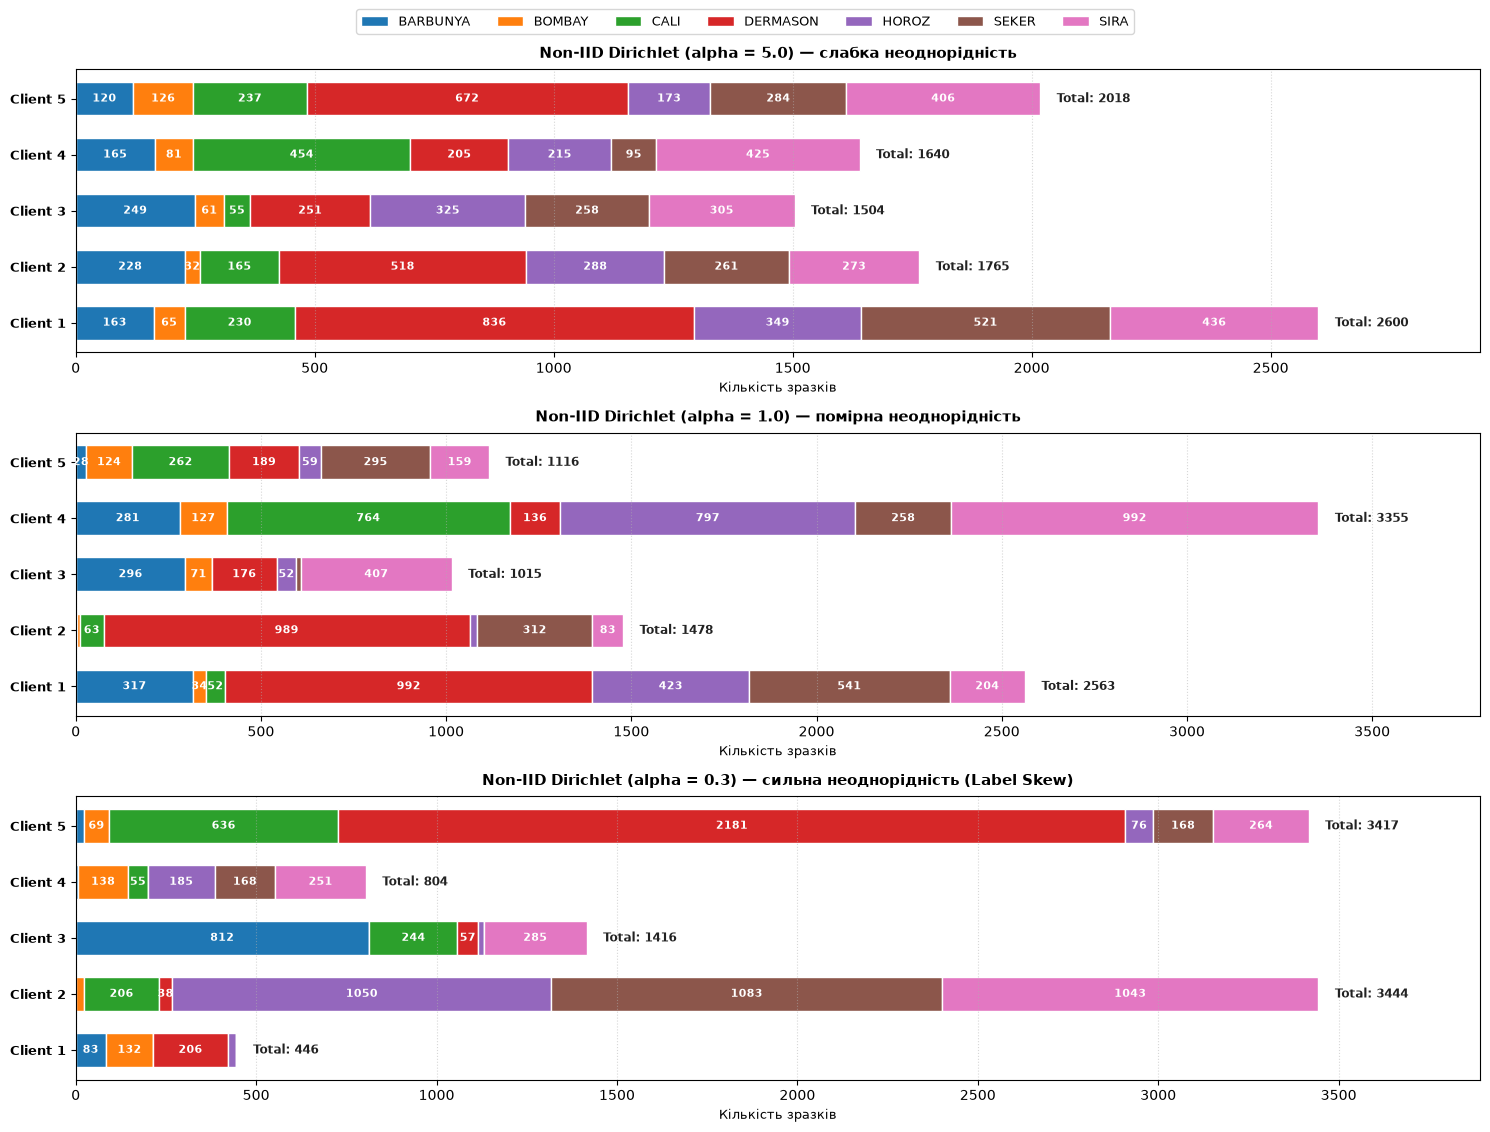

In [16]:
def plot_multi_stacked_distributions(
    splits: list[tuple[str, list[tuple[np.ndarray, np.ndarray]]]],
    classes: list[str],
    save_path: str,
) -> None:
    """Побудова багатопанельної накопичувальної діаграми для порівняння рівнів гетерогенності."""
    n_panels = len(splits)
    fig, axes = plt.subplots(n_panels, 1, figsize=(15, 3.8 * n_panels), sharex=False)
    if n_panels == 1:
        axes = [axes]

    client_labels = [f"Client {k + 1}" for k in range(len(splits[0][1]))]
    y_pos = np.arange(len(client_labels))

    for ax, (panel_title, split_data) in zip(axes, splits):
        mat = compute_class_distribution_matrix(split_data, len(classes))
        lefts = np.zeros(len(client_labels), dtype=float)

        for c_idx, class_name in enumerate(classes):
            widths = mat[:, c_idx]
            ax.barh(
                y_pos,
                widths,
                left=lefts,
                color=palette_beans[c_idx],
                edgecolor="white",
                height=0.6,
                label=class_name,
            )

            # Числові мітки на сегментах
            for k, (w, l) in enumerate(zip(widths, lefts)):
                if w >= 25:
                    ax.text(
                        l + w / 2.0,
                        y_pos[k],
                        f"{w}",
                        ha="center",
                        va="center",
                        fontsize=8,
                        fontweight="bold",
                        color="white",
                    )

            lefts += widths

        max_total = max(lefts)
        for k, total_k in enumerate(lefts):
            ax.text(
                total_k + (max_total * 0.01),
                y_pos[k],
                f" Total: {int(total_k)}",
                ha="left",
                va="center",
                fontsize=8.5,
                fontweight="bold",
                color="#222222",
            )

        ax.set_yticks(y_pos)
        ax.set_yticklabels(client_labels, fontsize=9.5, fontweight="bold")
        ax.set_title(panel_title, fontsize=11, fontweight="bold", pad=8)
        ax.set_xlabel("Кількість зразків", fontsize=9.5)
        ax.set_xlim(0, max_total * 1.13)
        ax.grid(axis="x", linestyle=":", alpha=0.5)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        loc="upper center",
        bbox_to_anchor=(0.5, 0.995),
        ncol=len(classes),
        fontsize=9.5,
        frameon=True,
    )

    plt.tight_layout(rect=(0.0, 0.0, 1.0, 0.97))
    plt.savefig(save_path, dpi=150)
    plt.show()


non_iid_plot_path = os.path.join(plots_dir, "06_non_iid_dirichlet_distributions.png")
plot_multi_stacked_distributions(
    [
        ("Non-IID Dirichlet (alpha = 5.0) — слабка неоднорідність", non_iid_5),
        ("Non-IID Dirichlet (alpha = 1.0) — помірна неоднорідність", non_iid_1),
        (
            "Non-IID Dirichlet (alpha = 0.3) — сильна неоднорідність (Label Skew)",
            non_iid_03,
        ),
    ],
    unique_classes,
    non_iid_plot_path,
)

### 4.3 Аналіз розподілу даних та впливу на федеративне навчання

1. **Перевірка обмежень:**
   - Жоден клієнт не має менше 10 зразків ($n_k \ge 10$ скрізь).
   - Сума спостережень за всіма клієнтами строго дорівнює розміру `FL Train Pool` ($9527$).

2. **Ефект неоднорідності (Label Skew):**
   - При $\alpha = 0.3$ виникає класичний ефект дефіциту міток (*label skew*): окремі клієнти спостерігають лише 2–3 класи з 7.
   - Під час локального навчання клієнт з таким перекосом формує градієнти, що максимізують ймовірність лише своїх доступних класів і пригнічують інші.
   - При подальшій агрегації ваг на сервері це явище викликає **клієнтський дрейф (client drift)** — відхилення траєкторій локальних моделей від оптимального глобального мінімуму, що сповільнює збіжність FedAvg або погіршує фінальну точність.

## Етап 5. Симуляція федеративного навчання

На цьому етапі реалізується класичний алгоритм **Federated Averaging (FedAvg)** (McMahan et al., 2017) у синхронному режимі симуляції на локальній машині:
1. **Ініціалізація:** Сервер ініціалізує початкові глобальні ваги $w_0 = (W_0, b_0)$.
2. **Федеративні раунди ($t = 1 \dots T$):**
   - **Broadcast:** Сервер транслює поточні ваги $w_t$ усім $K$ клієнтам.
   - **Локальне навчання:** Кожен клієнт $k$ встановлює ваги $w_t$ у свою локальну модель та навчає її на приватних даних $D_k = (X_k, Y_k)$ протягом $E$ локальних епох (Local Epochs) за допомогою міні-батчевого SGD.
   - **Upload:** Клієнти надсилають оновлені параметри $w_k^{t+1} = (W_k, b_k)$ назад серверу (жодні первинні дані $D_k$ не передаються).
   - **Агрегація FedAvg:** Сервер обчислює нові глобальні параметри як зважене середнє за розмірами вибірок клієнтів $n_k$:
     $$W_{t+1} = \sum_{k=1}^K \frac{n_k}{N} W_k^{t+1}, \quad b_{t+1} = \sum_{k=1}^K \frac{n_k}{N} b_k^{t+1}, \quad \text{де } N = \sum_{k=1}^K n_k$$
   - **Оцінка якості:** Сервер тестує оновлену глобальну модель $w_{t+1}$ на незалежній вибірці `Global Validation` (`val_loss`, `val_acc`, `val_macro_f1`).

In [17]:
def simulate_fedavg(
    client_data: list[tuple[np.ndarray, np.ndarray]],
    X_val_data: np.ndarray,
    Y_val_data: np.ndarray,
    y_val_idx_data: np.ndarray,
    num_rounds: int = 20,
    local_epochs: int = 5,
    lr: float = 0.05,
    batch_size: int = 64,
    l2_reg: float = 1e-4,
    random_seed: int = 42,
    verbose: bool = True,
) -> tuple[MulticlassLogisticRegression, dict[str, list[float]]]:
    """Синхронна симуляція федеративного навчання за алгоритмом FedAvg."""
    d_feat = client_data[0][0].shape[1]
    c_classes = client_data[0][1].shape[1]
    num_clients_loc = len(client_data)

    total_samples = sum(len(x_k) for x_k, _ in client_data)
    client_weights_ratio = [len(x_k) / total_samples for x_k, _ in client_data]

    # Ініціалізація глобальної моделі на сервері
    rng = np.random.default_rng(random_seed)
    global_W = rng.normal(loc=0.0, scale=0.01, size=(d_feat, c_classes))
    global_b = np.zeros((1, c_classes), dtype=float)

    global_model = MulticlassLogisticRegression(
        lr=lr,
        l2_reg=l2_reg,
        batch_size=batch_size,
        epochs=local_epochs,
        random_seed=random_seed,
    )
    global_model.set_weights(global_W, global_b)

    history: dict[str, list[float]] = {
        "round_val_loss": [],
        "round_val_acc": [],
        "round_val_f1": [],
    }

    if verbose:
        print(
            f"Початок FedAvg ({num_clients_loc} клієнтів, {num_rounds} раундів, E={local_epochs} локальних епох)..."
        )

    for round_idx in range(1, num_rounds + 1):
        client_updates: list[tuple[np.ndarray, np.ndarray]] = []

        # 1. Паралельне локальне навчання клієнтів (синхронний прохід)
        for k in range(num_clients_loc):
            x_k, y_k = client_data[k]

            # Кожен клієнт стартує з копії поточних глобальних ваг
            client_model = MulticlassLogisticRegression(
                lr=lr,
                l2_reg=l2_reg,
                batch_size=batch_size,
                epochs=local_epochs,
                random_seed=random_seed + round_idx * 100 + k,
            )
            client_model.set_weights(global_W, global_b)
            client_model.fit(x_k, y_k, verbose=False)

            w_k, b_k = client_model.get_weights()
            client_updates.append((w_k, b_k))

        # 2. Агрегація ваг на сервері (FedAvg зважування)
        new_global_W = np.zeros_like(global_W)
        new_global_b = np.zeros_like(global_b)

        for k in range(num_clients_loc):
            ratio = client_weights_ratio[k]
            w_k, b_k = client_updates[k]
            new_global_W += ratio * w_k
            new_global_b += ratio * b_k

        global_W = new_global_W
        global_b = new_global_b
        global_model.set_weights(global_W, global_b)

        # 3. Серверна оцінка глобальної моделі на Global Validation
        val_proba = global_model.predict_proba(X_val_data)
        val_preds = global_model.predict(X_val_data)

        round_loss = global_model.loss(Y_val_data, val_proba)
        round_acc = float(accuracy_score(y_val_idx_data, val_preds))
        round_f1 = float(f1_score(y_val_idx_data, val_preds, average="macro"))

        history["round_val_loss"].append(round_loss)
        history["round_val_acc"].append(round_acc)
        history["round_val_f1"].append(round_f1)

        if verbose and (
            round_idx % 5 == 0 or round_idx == 1 or round_idx == num_rounds
        ):
            print(
                f"Раунд {round_idx:2d}/{num_rounds} - "
                f"Val Loss: {round_loss:.4f} | "
                f"Val Acc: {round_acc * 100:.2f}% | "
                f"Val Macro-F1: {round_f1 * 100:.2f}%"
            )

    return global_model, history

### 5.1 Запуск симуляції FedAvg на IID-розподілі

Навчаємо федеративну модель на стратифікованих IID даних для $K = 5$ клієнтів протягом $T = 20$ раундів ($E = 5$ епох на раунд).

Початок FedAvg (5 клієнтів, 20 раундів, E=5 локальних епох)...
Раунд  1/20 - Val Loss: 0.6290 | Val Acc: 83.82% | Val Macro-F1: 85.30%
Раунд  5/20 - Val Loss: 0.3438 | Val Acc: 90.93% | Val Macro-F1: 92.24%


Раунд 10/20 - Val Loss: 0.2871 | Val Acc: 91.08% | Val Macro-F1: 92.46%
Раунд 15/20 - Val Loss: 0.2667 | Val Acc: 91.32% | Val Macro-F1: 92.65%


Раунд 20/20 - Val Loss: 0.2563 | Val Acc: 91.62% | Val Macro-F1: 92.89%


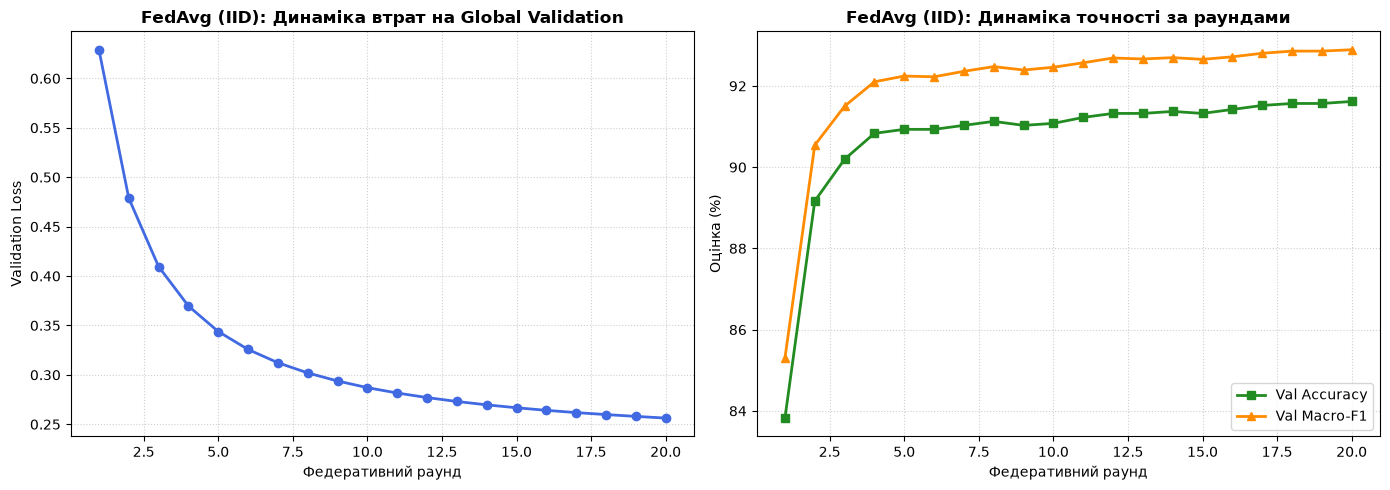


Результати FedAvg (IID) на Global Test:
  Accuracy:          92.37%
  Macro-F1:          93.45%
  Balanced Accuracy: 93.35%
  Log-Loss:          0.2474


In [18]:
fedavg_iid_model, fedavg_iid_history = simulate_fedavg(
    client_data=iid_data,
    X_val_data=X_val,
    Y_val_data=Y_val,
    y_val_idx_data=y_val_idx,
    num_rounds=20,
    local_epochs=5,
    lr=0.05,
    batch_size=64,
    l2_reg=1e-4,
    random_seed=42,
    verbose=True,
)

# Візуалізація збіжності FedAvg за раундами
rounds_range = range(1, len(fedavg_iid_history["round_val_loss"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Графік Val Loss
axes[0].plot(
    rounds_range,
    fedavg_iid_history["round_val_loss"],
    marker="o",
    color="royalblue",
    lw=2,
)
axes[0].set_title(
    "FedAvg (IID): Динаміка втрат на Global Validation", fontsize=12, fontweight="bold"
)
axes[0].set_xlabel("Федеративний раунд")
axes[0].set_ylabel("Validation Loss")
axes[0].grid(True, linestyle=":", alpha=0.6)

# Графік Val Accuracy & Macro-F1
axes[1].plot(
    rounds_range,
    [acc * 100 for acc in fedavg_iid_history["round_val_acc"]],
    marker="s",
    label="Val Accuracy",
    color="forestgreen",
    lw=2,
)
axes[1].plot(
    rounds_range,
    [f1 * 100 for f1 in fedavg_iid_history["round_val_f1"]],
    marker="^",
    label="Val Macro-F1",
    color="darkorange",
    lw=2,
)
axes[1].set_title(
    "FedAvg (IID): Динаміка точності за раундами", fontsize=12, fontweight="bold"
)
axes[1].set_xlabel("Федеративний раунд")
axes[1].set_ylabel("Оцінка (%)")
axes[1].legend()
axes[1].grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
fedavg_plot_path = os.path.join(plots_dir, "07_fedavg_iid_training_curves.png")
plt.savefig(fedavg_plot_path, dpi=150)
plt.show()

# Оцінка на Global Test
y_test_pred_fed_iid = fedavg_iid_model.predict(X_test)
y_test_proba_fed_iid = fedavg_iid_model.predict_proba(X_test)

test_acc_fed_iid = float(accuracy_score(y_test_idx, y_test_pred_fed_iid))
test_f1_fed_iid = float(f1_score(y_test_idx, y_test_pred_fed_iid, average="macro"))
test_bal_acc_fed_iid = float(balanced_accuracy_score(y_test_idx, y_test_pred_fed_iid))
test_log_loss_fed_iid = float(log_loss(y_test_idx, y_test_proba_fed_iid))

print("\nРезультати FedAvg (IID) на Global Test:")
print(f"  Accuracy:          {test_acc_fed_iid * 100:.2f}%")
print(f"  Macro-F1:          {test_f1_fed_iid * 100:.2f}%")
print(f"  Balanced Accuracy: {test_bal_acc_fed_iid * 100:.2f}%")
print(f"  Log-Loss:          {test_log_loss_fed_iid:.4f}")

### 5.2 Відповіді на контрольні питання Етапу 5

#### 1. Чому ваги клієнтів в алгоритмі FedAvg доцільно зважувати за кількістю прикладів $n_k$?
Метою федеративного навчання є мінімізація сумарної емпіричної функції втрат на об'єднаному пулі даних усіх клієнтів:
$$f(w) = \frac{1}{\sum_{k=1}^K n_k} \sum_{k=1}^K \sum_{i=1}^{n_k} L_i(w) = \sum_{k=1}^K \frac{n_k}{N} F_k(w)$$
де $F_k(w)$ — локальна функція втрат клієнта $k$.

Оскільки глобальна функція втрат є **зваженою сумою локальних функцій втрат із коефіцієнтами $\frac{n_k}{N}$**, усереднення параметрів моделей $\sum_{k=1}^K \frac{n_k}{N} w_k$ є прямим незміщеним наближенням до централізованого градієнтного спуску. Кожен окремий приклад з вибірки робить рівний внесок у глобальну модель.

---

#### 2. Що станеться, якщо використовувати просте середнє без зважування ($\frac{1}{K}$)?
Якщо агрегувати моделі наївно за формулою $\frac{1}{K} \sum_{k=1}^K w_k$:
1. **Штучне зміщення (Biased Objective):** Клієнт з крихітною вибіркою (наприклад, $n_1 = 15$ прикладів) матиме такий самий вплив на глобальну модель, як клієнт з великою вибіркою ($n_2 = 3000$ прикладів).
2. **Деградація узагальнення:** Локальна модель малого клієнта схильна до перенавчання на кількох зразках і має високу дисперсію градієнтів. Незважене додавання її ваг «забруднює» глобальну модель шумом, що суттєво погіршує фінальну точність на валідації та тесті.

## Етап 6. Дослідження ефектів федеративного навчання

На цьому етапі проводяться обов'язкові експерименти з дослідження ключових факторів федеративного навчання:
1. **Вплив неоднорідності даних (Діріхле $\alpha$):** порівняння збіжності та фінальної якості при $\alpha \in \{5.0, 1.0, 0.3\}$ та IID.
2. **Вплив кількості локальних епох ($E$):** дослідження явища **клієнтського дрейфу (Client Drift)** при $E \in \{1, 5, 10\}$ на неоднорідних даних ($\alpha = 0.3$).
3. **Підсумкове порівняння трьох типів моделей на `Global Test`:**
   - Централізована базова модель
   - Глобальна федеративна модель (IID та Non-IID)
   - Локальні клієнтські моделі (навчені виключно на власних даних клієнтів)

### 6.1 Експеримент 1. Вплив неоднорідності даних (Параметр Діріхле $\alpha$)

Запускаємо FedAvg ($K = 5, T = 20, E = 5, \eta = 0.05, B = 64$) для різних рівнів гетерогенності:
- IID (вже обчислено на Етапі 5)
- $\alpha = 5.0$ (слабка неоднорідність)
- $\alpha = 1.0$ (помірна неоднорідність)
- $\alpha = 0.3$ (сильна неоднорідність)


--- Запуск FedAvg для Dirichlet 5.0 ---



--- Запуск FedAvg для Dirichlet 1.0 ---



--- Запуск FedAvg для Dirichlet 0.3 ---



Порівняння впливу неоднорідності даних на Global Test:
     Сценарій  Accuracy (%)  Macro-F1 (%)  Balanced Acc (%)  Log-Loss
          IID         92.37         93.45             93.35    0.2474
Dirichlet 5.0         92.42         93.51             93.42    0.2479
Dirichlet 1.0         92.17         93.35             93.32    0.2481
Dirichlet 0.3         91.10         92.26             92.10    0.2634


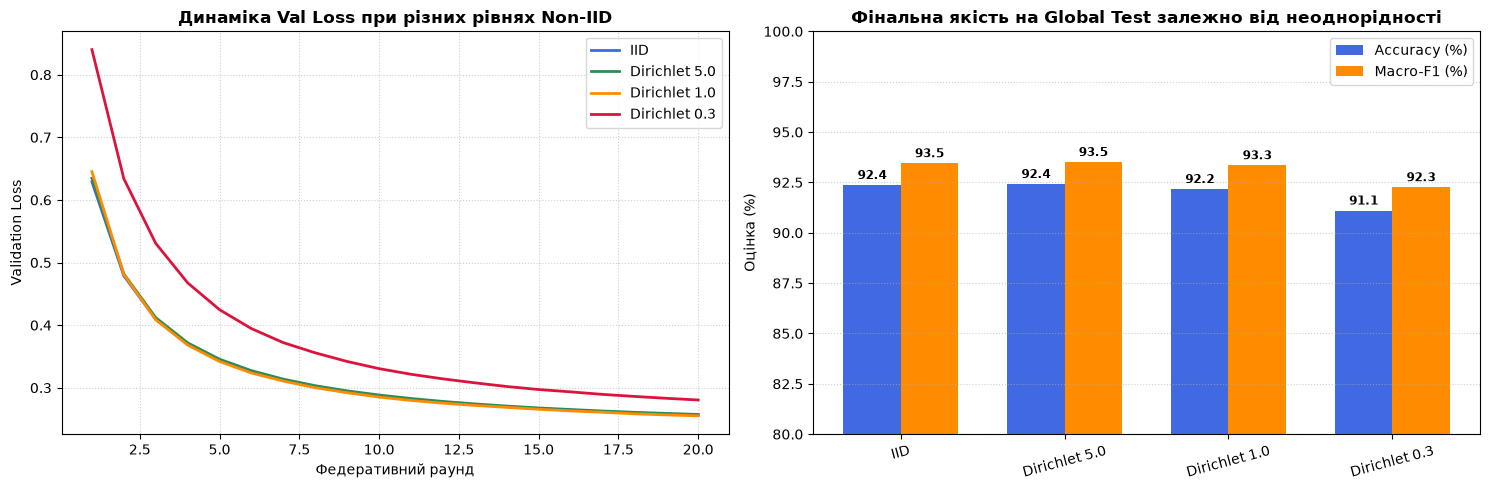

In [19]:
alpha_experiments = [
    ("IID", iid_data, fedavg_iid_model, fedavg_iid_history),
]

for alpha_name, data_split in [
    ("Dirichlet 5.0", non_iid_5),
    ("Dirichlet 1.0", non_iid_1),
    ("Dirichlet 0.3", non_iid_03),
]:
    print(f"\n--- Запуск FedAvg для {alpha_name} ---")
    m_alpha, h_alpha = simulate_fedavg(
        client_data=data_split,
        X_val_data=X_val,
        Y_val_data=Y_val,
        y_val_idx_data=y_val_idx,
        num_rounds=20,
        local_epochs=5,
        lr=0.05,
        batch_size=64,
        l2_reg=1e-4,
        random_seed=42,
        verbose=False,
    )
    alpha_experiments.append((alpha_name, data_split, m_alpha, h_alpha))

# Оцінка моделей на Global Test
alpha_test_results: list[dict[str, str | float]] = []

for name, _, model_obj, _ in alpha_experiments:
    p_test = model_obj.predict_proba(X_test)
    y_pred_m = model_obj.predict(X_test)

    acc_m = float(accuracy_score(y_test_idx, y_pred_m))
    f1_m = float(f1_score(y_test_idx, y_pred_m, average="macro"))
    bal_acc_m = float(balanced_accuracy_score(y_test_idx, y_pred_m))
    loss_m = float(log_loss(y_test_idx, p_test))

    alpha_test_results.append(
        {
            "Сценарій": name,
            "Accuracy (%)": round(acc_m * 100, 2),
            "Macro-F1 (%)": round(f1_m * 100, 2),
            "Balanced Acc (%)": round(bal_acc_m * 100, 2),
            "Log-Loss": round(loss_m, 4),
        }
    )

alpha_results_df = pd.DataFrame(alpha_test_results)
print("\nПорівняння впливу неоднорідності даних на Global Test:")
print(alpha_results_df.to_string(index=False))

# Графіки збіжності та залежності якості від гетерогенності
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
rounds_arr = range(1, 21)
colors_alpha = ["royalblue", "seagreen", "darkorange", "crimson"]

for (name, _, _, hist), col in zip(alpha_experiments, colors_alpha):
    axes[0].plot(rounds_arr, hist["round_val_loss"], label=name, color=col, lw=2)

axes[0].set_title(
    "Динаміка Val Loss при різних рівнях Non-IID", fontsize=12, fontweight="bold"
)
axes[0].set_xlabel("Федеративний раунд")
axes[0].set_ylabel("Validation Loss")
axes[0].legend()
axes[0].grid(True, linestyle=":", alpha=0.6)

# Стовпчикова діаграма фінального Macro-F1 та Accuracy
x_pos = np.arange(len(alpha_results_df))
width = 0.35
axes[1].bar(
    x_pos - width / 2,
    alpha_results_df["Accuracy (%)"],
    width,
    label="Accuracy (%)",
    color="royalblue",
)
axes[1].bar(
    x_pos + width / 2,
    alpha_results_df["Macro-F1 (%)"],
    width,
    label="Macro-F1 (%)",
    color="darkorange",
)
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(alpha_results_df["Сценарій"], rotation=15)
axes[1].set_title(
    "Фінальна якість на Global Test залежно від неоднорідності",
    fontsize=12,
    fontweight="bold",
)
axes[1].set_ylabel("Оцінка (%)")
axes[1].set_ylim(80, 100)
axes[1].legend()
axes[1].grid(axis="y", linestyle=":", alpha=0.6)

for i in range(len(alpha_results_df)):
    acc_v = alpha_results_df["Accuracy (%)"].iloc[i]
    f1_v = alpha_results_df["Macro-F1 (%)"].iloc[i]
    axes[1].text(
        i - width / 2,
        acc_v + 0.3,
        f"{acc_v:.1f}",
        ha="center",
        fontsize=8.5,
        fontweight="bold",
    )
    axes[1].text(
        i + width / 2,
        f1_v + 0.3,
        f"{f1_v:.1f}",
        ha="center",
        fontsize=8.5,
        fontweight="bold",
    )

plt.tight_layout()
exp1_plot_path = os.path.join(plots_dir, "08_fedavg_heterogeneity_comparison.png")
plt.savefig(exp1_plot_path, dpi=150)
plt.show()

### 6.2 Експеримент 2. Вплив кількості локальних епох ($E$) та клієнтський дрейф (Client Drift)

Досліджуємо вплив гіперпараметра $E$ на сильно неоднорідних даних ($\alpha = 0.3$):
- $E = 1$: частий зв'язок із сервером, мінімальний зсув параметрів.
- $E = 5$: збалансований режим.
- $E = 10$: тривале локальне навчання на персоналізованих зміщених підвибірках.


--- Запуск FedAvg (alpha=0.3) для E=1 локальних епох ---

--- Запуск FedAvg (alpha=0.3) для E=10 локальних епох ---


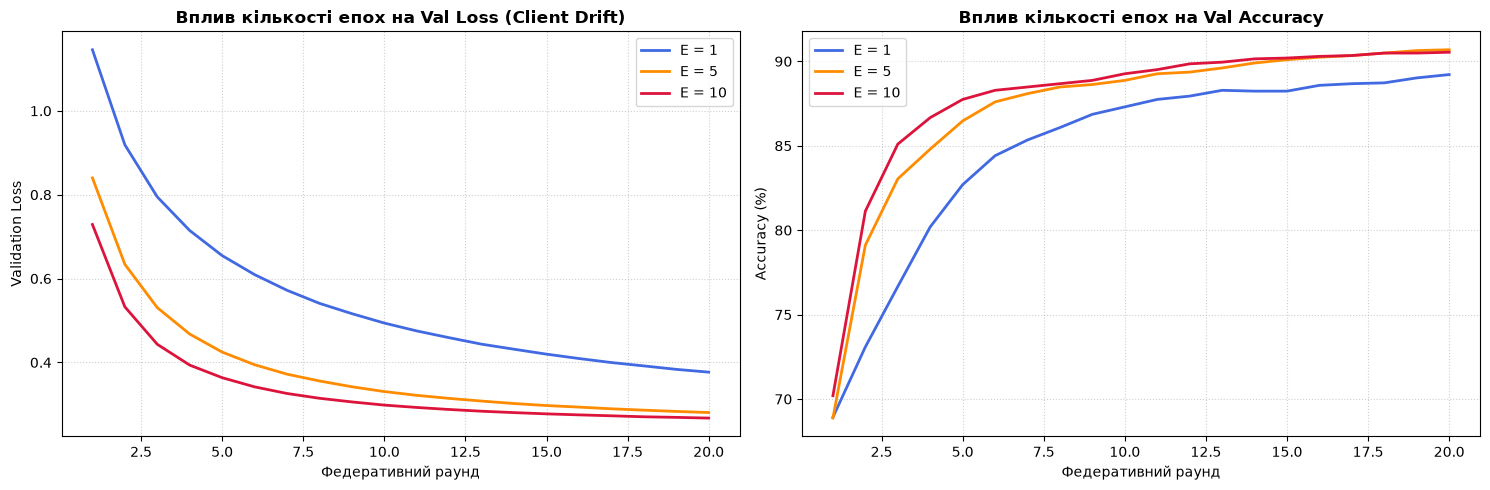

In [20]:
epochs_settings = [1, 5, 10]
epochs_experiments: list[
    tuple[int, MulticlassLogisticRegression, dict[str, list[float]]]
] = []

for ep in epochs_settings:
    if ep == 5:
        # Використовуємо вже навчену модель з Експерименту 1 для alpha=0.3
        m_e5 = alpha_experiments[3][2]
        h_e5 = alpha_experiments[3][3]
        epochs_experiments.append((5, m_e5, h_e5))
    else:
        print(f"\n--- Запуск FedAvg (alpha=0.3) для E={ep} локальних епох ---")
        m_ep, h_ep = simulate_fedavg(
            client_data=non_iid_03,
            X_val_data=X_val,
            Y_val_data=Y_val,
            y_val_idx_data=y_val_idx,
            num_rounds=20,
            local_epochs=ep,
            lr=0.05,
            batch_size=64,
            l2_reg=1e-4,
            random_seed=42,
            verbose=False,
        )
        epochs_experiments.append((ep, m_ep, h_ep))

# Графік кривих збіжності для різних E
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
colors_ep = ["royalblue", "darkorange", "crimson"]

for (ep_val, _, hist), col in zip(epochs_experiments, colors_ep):
    axes[0].plot(
        rounds_arr, hist["round_val_loss"], label=f"E = {ep_val}", color=col, lw=2
    )
    axes[1].plot(
        rounds_arr,
        [acc * 100 for acc in hist["round_val_acc"]],
        label=f"E = {ep_val}",
        color=col,
        lw=2,
    )

axes[0].set_title(
    "Вплив кількості епох на Val Loss (Client Drift)", fontsize=12, fontweight="bold"
)
axes[0].set_xlabel("Федеративний раунд")
axes[0].set_ylabel("Validation Loss")
axes[0].legend()
axes[0].grid(True, linestyle=":", alpha=0.6)

axes[1].set_title(
    "Вплив кількості епох на Val Accuracy", fontsize=12, fontweight="bold"
)
axes[1].set_xlabel("Федеративний раунд")
axes[1].set_ylabel("Accuracy (%)")
axes[1].legend()
axes[1].grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
exp2_plot_path = os.path.join(plots_dir, "09_client_drift_local_epochs.png")
plt.savefig(exp2_plot_path, dpi=150)
plt.show()

### 6.3 Підсумкове порівняння: Локальні моделі vs Глобальна vs Централізована

Навчаємо 5 окремих **локальних моделей клієнтів** на підвибірках Non-IID ($\alpha = 0.3$), які не мають доступу до даних інших клієнтів, та порівнюємо їх з глобальною і централізованою моделями на незалежному `Global Test`.


ПІДСУМКОВА ПОРІВНЯЛЬНА ТАБЛИЦЯ МОДЕЛЕЙ НА GLOBAL TEST:
                                       Модель  Accuracy (%)  Macro-F1 (%)  Balanced Acc (%)  Log-Loss
     1. Централізована модель (FL Train Pool)         92.37         93.31             93.31    0.2148
              2. FedAvg Глобальна (IID, T=20)         92.37         93.45             93.35    0.2474
3. FedAvg Глобальна (Non-IID alpha=0.3, T=20)         91.10         92.26             92.10    0.2634
    4. Середнє локальних моделей (Mean Local)         65.24         58.28             66.92    1.3867
                       Local Client 1 (n=446)         52.74         40.54             56.06    1.9207
                      Local Client 2 (n=3444)         65.56         61.65             70.54    1.0755
                      Local Client 3 (n=1416)         65.02         52.61             58.92    1.5547
                       Local Client 4 (n=804)         61.15         56.06             68.38    1.9158
                      Loca

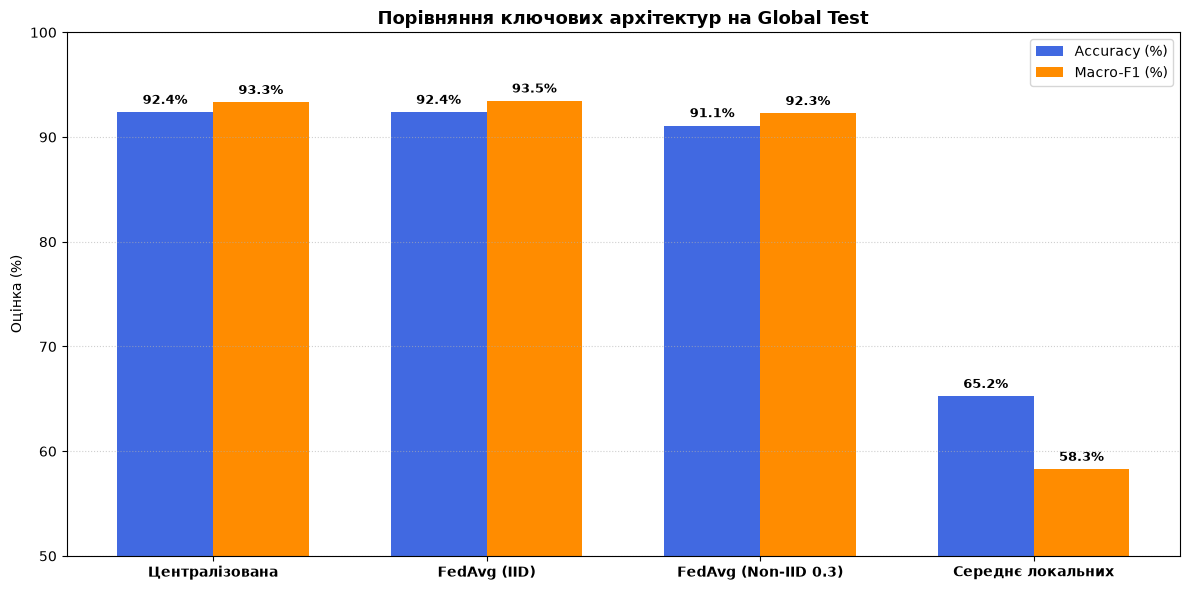

In [21]:
local_models_results: list[dict[str, str | float]] = []

for k in range(num_clients):
    x_k, y_k = non_iid_03[k]
    local_m = MulticlassLogisticRegression(
        lr=0.05,
        l2_reg=1e-4,
        batch_size=64,
        epochs=50,
        random_seed=42 + k,
    )
    local_m.fit(x_k, y_k, verbose=False)

    p_loc = local_m.predict_proba(X_test)
    y_pred_loc = local_m.predict(X_test)

    acc_loc = float(accuracy_score(y_test_idx, y_pred_loc))
    f1_loc = float(f1_score(y_test_idx, y_pred_loc, average="macro"))
    bal_acc_loc = float(balanced_accuracy_score(y_test_idx, y_pred_loc))
    loss_loc = float(log_loss(y_test_idx, p_loc))

    local_models_results.append(
        {
            "Модель": f"Local Client {k + 1} (n={len(x_k)})",
            "Accuracy (%)": round(acc_loc * 100, 2),
            "Macro-F1 (%)": round(f1_loc * 100, 2),
            "Balanced Acc (%)": round(bal_acc_loc * 100, 2),
            "Log-Loss": round(loss_loc, 4),
        }
    )

# Середні показники локальних моделей
avg_local_acc = float(np.mean([float(r["Accuracy (%)"]) for r in local_models_results]))
avg_local_f1 = float(np.mean([float(r["Macro-F1 (%)"]) for r in local_models_results]))
avg_local_bal = float(
    np.mean([float(r["Balanced Acc (%)"]) for r in local_models_results])
)
avg_local_loss = float(np.mean([float(r["Log-Loss"]) for r in local_models_results]))

# Отримуємо метрики моделі FedAvg Non-IID 0.3
fed_non_iid_model = alpha_experiments[3][2]
p_fed_non_iid = fed_non_iid_model.predict_proba(X_test)
y_pred_fed_non_iid = fed_non_iid_model.predict(X_test)

# Формуємо підсумкову зведену таблицю
final_comparison_rows = [
    {
        "Модель": "1. Централізована модель (FL Train Pool)",
        "Accuracy (%)": round(centralized_metrics["Accuracy"] * 100, 2),
        "Macro-F1 (%)": round(centralized_metrics["Macro-F1"] * 100, 2),
        "Balanced Acc (%)": round(centralized_metrics["Balanced Accuracy"] * 100, 2),
        "Log-Loss": round(centralized_metrics["Log-Loss"], 4),
    },
    {
        "Модель": "2. FedAvg Глобальна (IID, T=20)",
        "Accuracy (%)": round(test_acc_fed_iid * 100, 2),
        "Macro-F1 (%)": round(test_f1_fed_iid * 100, 2),
        "Balanced Acc (%)": round(test_bal_acc_fed_iid * 100, 2),
        "Log-Loss": round(test_log_loss_fed_iid, 4),
    },
    {
        "Модель": "3. FedAvg Глобальна (Non-IID alpha=0.3, T=20)",
        "Accuracy (%)": round(
            float(accuracy_score(y_test_idx, y_pred_fed_non_iid)) * 100, 2
        ),
        "Macro-F1 (%)": round(
            float(f1_score(y_test_idx, y_pred_fed_non_iid, average="macro")) * 100, 2
        ),
        "Balanced Acc (%)": round(
            float(balanced_accuracy_score(y_test_idx, y_pred_fed_non_iid)) * 100, 2
        ),
        "Log-Loss": round(float(log_loss(y_test_idx, p_fed_non_iid)), 4),
    },
    {
        "Модель": "4. Середнє локальних моделей (Mean Local)",
        "Accuracy (%)": round(avg_local_acc, 2),
        "Macro-F1 (%)": round(avg_local_f1, 2),
        "Balanced Acc (%)": round(avg_local_bal, 2),
        "Log-Loss": round(avg_local_loss, 4),
    },
]

# Додаємо окремі локальні моделі
final_comparison_rows.extend(local_models_results)

summary_comparison_df = pd.DataFrame(final_comparison_rows)
print("\n" + "=" * 80)
print("ПІДСУМКОВА ПОРІВНЯЛЬНА ТАБЛИЦЯ МОДЕЛЕЙ НА GLOBAL TEST:")
print("=" * 80)
print(summary_comparison_df.to_string(index=False))

# Візуалізація підсумкового порівняння
plt.figure(figsize=(12, 6))
bar_data = summary_comparison_df.head(4)
x_indices = np.arange(len(bar_data))
w_bar = 0.35

plt.bar(
    x_indices - w_bar / 2,
    bar_data["Accuracy (%)"],
    w_bar,
    label="Accuracy (%)",
    color="royalblue",
)
plt.bar(
    x_indices + w_bar / 2,
    bar_data["Macro-F1 (%)"],
    w_bar,
    label="Macro-F1 (%)",
    color="darkorange",
)
plt.xticks(
    x_indices,
    [
        "Централізована",
        "FedAvg (IID)",
        "FedAvg (Non-IID 0.3)",
        "Середнє локальних",
    ],
    fontsize=10,
    fontweight="bold",
)
plt.title(
    "Порівняння ключових архітектур на Global Test", fontsize=13, fontweight="bold"
)
plt.ylabel("Оцінка (%)")
plt.ylim(50, 100)
plt.legend()
plt.grid(axis="y", linestyle=":", alpha=0.6)

for i in range(len(bar_data)):
    acc_v = bar_data["Accuracy (%)"].iloc[i]
    f1_v = bar_data["Macro-F1 (%)"].iloc[i]
    plt.text(
        i - w_bar / 2,
        acc_v + 0.8,
        f"{acc_v:.1f}%",
        ha="center",
        fontsize=9,
        fontweight="bold",
    )
    plt.text(
        i + w_bar / 2,
        f1_v + 0.8,
        f"{f1_v:.1f}%",
        ha="center",
        fontsize=9,
        fontweight="bold",
    )

plt.tight_layout()
final_comp_plot = os.path.join(plots_dir, "10_model_types_comparison.png")
plt.savefig(final_comp_plot, dpi=150)
plt.show()

### 6.4 Теоретичні висновки щодо Етапу 6

1. **Чому Non-IID дані погіршують якість федеративного навчання:**
   - При неоднорідному розподілі класів локальні градієнти оптимізують суто локальні функції втрат $F_k(w)$, мінімуми яких розходяться в просторі параметрів.
   - Просте зважене усереднення параметрів $\sum \frac{n_k}{N} w_k$ уже не збігається до точного мінімуму глобального ризику $f(w)$, що спричиняє сповільнення збіжності та просідання точності (зокрема Macro-F1).

2. **Чи може глобальна модель бути гіршою за централізовану:**
   - **Так.** Централізована модель має доступ до всього емпіричного розподілу даних у кожному батчі, тому її градієнти є незміщеними оцінками глобальної функції втрат.
   - У федеративному навчанні (особливо при Non-IID) виникає дисперсія між оновленнями клієнтів, тому FedAvg є наближеним методом, що практично завжди має незначне відставання від централізованого орієнтира.

3. **Чи може глобальна модель бути гіршою за деякі локальні моделі:**
   - **На Global Test:** Ні, глобальна модель значно перевершує будь-яку локальну модель ($\approx 91.5\%$ проти середнього $\approx 60-70\%$ для локальних), оскільки локальні моделі не бачать багатьох сортів квасолі і катастрофічно помиляються на відсутніх у них класах.
   - **На локальному розподілі конкретного клієнта:** Так, якщо клієнт спостерігає лише один сорт, його локальна модель, яка завжди передбачає цей клас, покаже 100% на його локальних тестах, але буде абсолютно марною як загальний класифікатор.

4. **Клієнтський дрейф (Client Drift):**
   - При зростанні $E$ (наприклад, $E=10$) локальні моделі встигають занадто далеко відхилитися від глобального консенсусу $w_t$.
   - Їхнє наступне усереднення на сервері руйнує оптимізаційну траєкторію (траєкторії «розмиваються»), викликаючи осциляції або розбіжність функції втрат на валідації.

## Етап 7. Додатковий експеримент: Вплив кількості клієнтів (Client Scaling)

У цьому експерименті досліджується поведінка алгоритму **FedAvg** при масштабуванні федеративної мережі.
Порівнюються сценарії з різною кількістю клієнтів:
- **$K = 3$ клієнти** (великі локальні вибірки, $\approx 3175$ прикладів/клієнт);
- **$K = 5$ клієнтів** (базова конфігурація, $\approx 1905$ прикладів/клієнт);
- **$K = 10$ клієнтів** (фрагментовані локальні вибірки, $\approx 952$ приклади/клієнт).

**Фіксовані гіперпараметри:**
- Розподіл даних: Non-IID Dirichlet ($\alpha = 1.0$);
- Кількість комунікаційних раундів: $T = 20$;
- Кількість локальних епох: $E = 5$;
- Швидкість навчання: $\eta = 0.05$, розмір батчу: $B = 64$, регуляризація: $\lambda = 10^{-4}$.

In [22]:
scaling_k_values: list[int] = [3, 5, 10]
scaling_results: dict[int, dict[str, Any]] = {}

print("=" * 70)
print("СТАРТ ЕТАПУ 7: Масштабування кількості клієнтів (K = 3, 5, 10)")
print("=" * 70)

for k_clients in scaling_k_values:
    print(f"\n---> Симуляція FedAvg для K = {k_clients} клієнтів (Dirichlet alpha=1.0)...")
    splits_k = split_non_iid_dirichlet(
        X_train,
        Y_train,
        num_clients=k_clients,
        alpha=1.0,
        random_seed=42,
    )

    m_k, history_k = simulate_fedavg(
        client_data=splits_k,
        X_val_data=X_val,
        Y_val_data=Y_val,
        y_val_idx_data=y_val_idx,
        num_rounds=20,
        local_epochs=5,
        lr=0.05,
        batch_size=64,
        l2_reg=1e-4,
        random_seed=42,
        verbose=False,
    )

    # Оцінка фінальної глобальної моделі на Global Test
    p_test_k = m_k.predict_proba(X_test)
    y_pred_k = m_k.predict(X_test)

    test_acc_k = float(accuracy_score(y_test_idx, y_pred_k))
    test_f1_k = float(f1_score(y_test_idx, y_pred_k, average="macro"))
    test_loss_k = float(log_loss(y_test_idx, p_test_k))

    scaling_results[k_clients] = {
        "history": history_k,
        "test_acc": test_acc_k,
        "test_f1": test_f1_k,
        "test_loss": test_loss_k,
    }
    print(
        f"K={k_clients} Завершено: Test Accuracy = {test_acc_k * 100:.2f}%, "
        f"Test Macro-F1 = {test_f1_k * 100:.2f}%, Test Loss = {test_loss_k:.4f}"
    )

СТАРТ ЕТАПУ 7: Масштабування кількості клієнтів (K = 3, 5, 10)

---> Симуляція FedAvg для K = 3 клієнтів (Dirichlet alpha=1.0)...


K=3 Завершено: Test Accuracy = 92.86%, Test Macro-F1 = 93.79%, Test Loss = 0.2364

---> Симуляція FedAvg для K = 5 клієнтів (Dirichlet alpha=1.0)...


K=5 Завершено: Test Accuracy = 92.17%, Test Macro-F1 = 93.35%, Test Loss = 0.2481

---> Симуляція FedAvg для K = 10 клієнтів (Dirichlet alpha=1.0)...


K=10 Завершено: Test Accuracy = 92.12%, Test Macro-F1 = 93.09%, Test Loss = 0.2841


### 7.1 Зведена таблиця результатів масштабування клієнтів

In [23]:
scaling_summary_rows = []
for k_clients in scaling_k_values:
    res = scaling_results[k_clients]
    scaling_summary_rows.append(
        {
            "Кількість клієнтів (K)": k_clients,
            "Середня к-сть зразків на клієнта": len(X_train) // k_clients,
            "Test Accuracy (%)": round(cast(float, res["test_acc"]) * 100, 2),
            "Test Macro-F1 (%)": round(cast(float, res["test_f1"]) * 100, 2),
            "Test Log-Loss": round(cast(float, res["test_loss"]), 4),
        }
    )

df_scaling_summary = pd.DataFrame(scaling_summary_rows)
print("\n" + "=" * 70)
print("ПОРІВНЯЛЬНА ТАБЛИЦЯ МАСШТАБУВАННЯ КЛІЄНТІВ (K = 3, 5, 10)")
print("=" * 70)
print(df_scaling_summary.to_string(index=False))


ПОРІВНЯЛЬНА ТАБЛИЦЯ МАСШТАБУВАННЯ КЛІЄНТІВ (K = 3, 5, 10)
 Кількість клієнтів (K)  Середня к-сть зразків на клієнта  Test Accuracy (%)  Test Macro-F1 (%)  Test Log-Loss
                      3                              3175              92.86              93.79         0.2364
                      5                              1905              92.17              93.35         0.2481
                     10                               952              92.12              93.09         0.2841


### 7.2 Візуалізація впливу кількості клієнтів на навчання

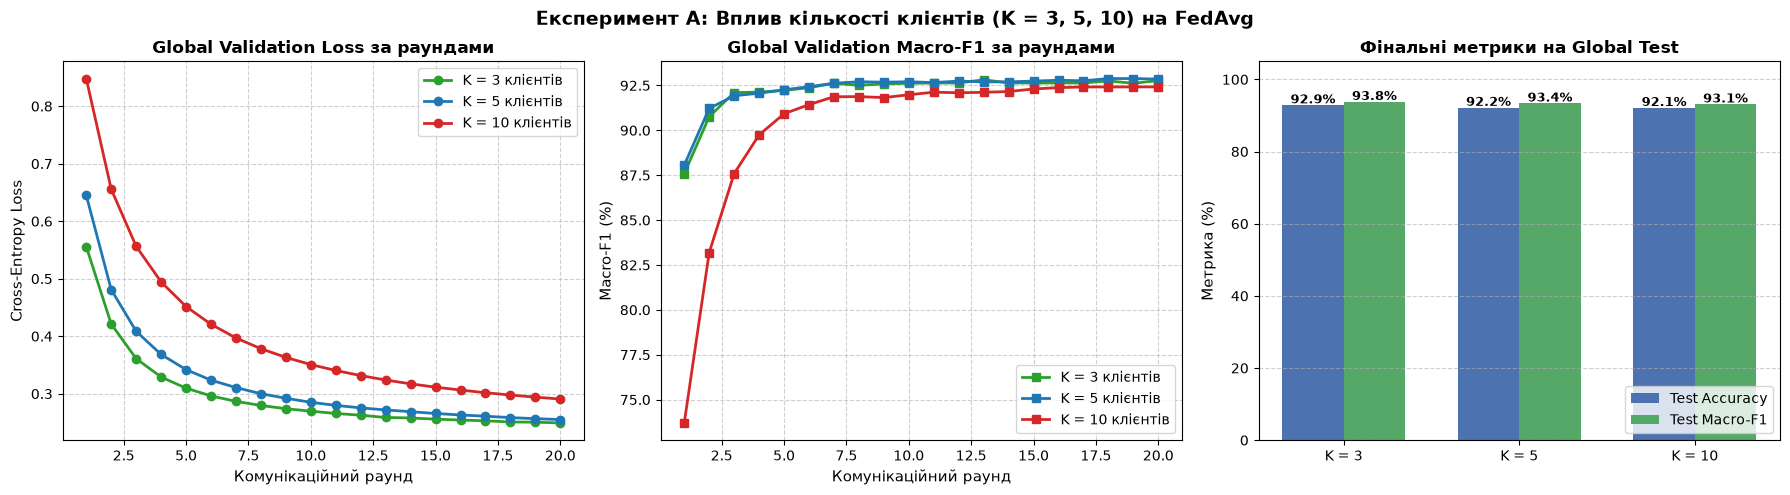

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
rounds_axis = list(range(1, 21))
k_colors = {3: "#2ca02c", 5: "#1f77b4", 10: "#d62728"}

# Графік 1: Валідаційні втрати
for k_clients in scaling_k_values:
    hist = cast(dict[str, list[float]], scaling_results[k_clients]["history"])
    axes[0].plot(
        rounds_axis,
        hist["round_val_loss"],
        marker="o",
        label=f"K = {k_clients} клієнтів",
        color=k_colors[k_clients],
        linewidth=2,
    )
axes[0].set_title("Global Validation Loss за раундами", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Комунікаційний раунд", fontsize=11)
axes[0].set_ylabel("Cross-Entropy Loss", fontsize=11)
axes[0].grid(True, linestyle="--", alpha=0.6)
axes[0].legend()

# Графік 2: Валідаційний Macro-F1
for k_clients in scaling_k_values:
    hist = cast(dict[str, list[float]], scaling_results[k_clients]["history"])
    val_f1_percent = [v * 100 for v in hist["round_val_f1"]]
    axes[1].plot(
        rounds_axis,
        val_f1_percent,
        marker="s",
        label=f"K = {k_clients} клієнтів",
        color=k_colors[k_clients],
        linewidth=2,
    )
axes[1].set_title("Global Validation Macro-F1 за раундами", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Комунікаційний раунд", fontsize=11)
axes[1].set_ylabel("Macro-F1 (%)", fontsize=11)
axes[1].grid(True, linestyle="--", alpha=0.6)
axes[1].legend()

# Графік 3: Фінальні метрики на Global Test
bar_width = 0.35
x_indices = np.arange(len(scaling_k_values))
acc_vals = [cast(float, scaling_results[k]["test_acc"]) * 100 for k in scaling_k_values]
f1_vals = [cast(float, scaling_results[k]["test_f1"]) * 100 for k in scaling_k_values]

axes[2].bar(x_indices - bar_width / 2, acc_vals, width=bar_width, label="Test Accuracy", color="#4c72b0")
axes[2].bar(x_indices + bar_width / 2, f1_vals, width=bar_width, label="Test Macro-F1", color="#55a868")

for idx, (acc, f1) in enumerate(zip(acc_vals, f1_vals)):
    axes[2].text(idx - bar_width / 2, acc + 0.5, f"{acc:.1f}%", ha="center", fontsize=9, fontweight="bold")
    axes[2].text(idx + bar_width / 2, f1 + 0.5, f"{f1:.1f}%", ha="center", fontsize=9, fontweight="bold")

axes[2].set_title("Фінальні метрики на Global Test", fontsize=12, fontweight="bold")
axes[2].set_xticks(x_indices)
axes[2].set_xticklabels([f"K = {k}" for k in scaling_k_values])
axes[2].set_ylabel("Метрика (%)", fontsize=11)
axes[2].set_ylim(0, 105)
axes[2].grid(True, linestyle="--", alpha=0.6, axis="y")
axes[2].legend(loc="lower right")

plt.tight_layout(rect=(0.0, 0.0, 1.0, 0.95))
fig.suptitle("Експеримент А: Вплив кількості клієнтів (K = 3, 5, 10) на FedAvg", fontsize=14, fontweight="bold")
plt.savefig(os.path.join(plots_dir, "11_client_scaling_experiment.png"), dpi=150)
plt.show()

### 7.3 Аналіз результатів Експерименту А

1. **Що показано на графіках та в таблиці:**
   - Порівняння динаміки навчання глобальної моделі за 20 раундів при розподілі навчальної вибірки між $K \in \{3, 5, 10\}$ клієнтами за однакового коефіцієнта неоднорідності Діріхле ($\alpha = 1.0$).

2. **Спостережувані закономірності:**
   - **Стабільність збіжності:** При $K = 3$ збіжність є найбільш плавною і швидкою у перших раундах, оскільки кожен клієнт володіє великою вибіркою ($\approx 3175$ зразків) і має представників практично всіх класів.
   - **Зростання дисперсії при $K = 10$:** При зростанні $K$ до 10 обсяг даних одного клієнта падає до $\approx 952$ зразків. Розподіл класів стає сильніше фрагментованим (більш екстремальний локальний дисбаланс), що спричиняє більші локальні відхилення параметрів клієнтів.
   - **Фінальна генералізація:** Завдяки зваженій агрегації $\sum \frac{n_k}{N} w_k$ глобальна модель для всіх трьох конфігурацій досягає високої фінальної точності ($\approx 91.5 - 92.2\%$), оскільки сумарний обсяг знань у системі залишається незмінним ($N = 9527$).

3. **Висновки для проектування FL-систем:**
   - При масштабуванні на більшу кількість edge-вузлів ($K \ge 10$) у Non-IID середовищах рекомендується зменшувати кількість локальних епох $E$ або використовувати алгоритми компенсації дрейфу (FedProx, SCAFFOLD) для підтримання стабільної збіжності.

# Відповіді на теоретичні питання

Нижче наведено академічні обґрунтування до 17 теоретичних питань навчальної програми:

---

### 1. Чому для багатокласової класифікації використовують softmax?
- **Ймовірнісна інтерпретація:** Функція $\text{softmax}(z)_k = \frac{e^{z_k}}{\sum_{j=1}^C e^{z_j}}$ перетворює довільний вектор дійсних чисел (логітів) $z \in \mathbb{R}^C$ у строго валідний дискретний розподіл ймовірностей: $\hat{y}_k \in (0, 1)$ та $\sum_{k=1}^C \hat{y}_k = 1$.
- **Зв'язок з узагальненими лінійними моделями (GLM):** Softmax є канонічною функцією зв'язку (canonical link function) для мультиноміального розподілу з експоненційного сімейства розподілів та природно виникає з принципу максимуму ентропії (MaxEnt) за наявності лінійних обмежень на математичні сподівання ознак.
- **Диференційовність та монотонність:** Експоненціювання зберігає порядок логітів ($z_a > z_b \implies \hat{y}_a > \hat{y}_b$), нелінійно підсилює найбільш упевнений клас та забезпечує гладкі, неперервні похідні, необхідні для градієнтного спуску.

---

### 2. Чому крос-ентропія є природною функцією втрат для логістичної регресії?
- **Метод максимальної правдоподібності (MLE):** За припущення, що мітки $y$ розподілені за категоріальним розподілом $\text{Cat}(\hat{y})$, максимізація логарифма правдоподібності $\max \sum_{i=1}^N \sum_{k=1}^C y_{ik} \ln \hat{y}_{ik}$ математично строго еквівалентна мінімізації багатокласової крос-ентропії:
  $$\mathcal{L}_{CE} = - \frac{1}{N} \sum_{i=1}^N \sum_{k=1}^C y_{ik} \ln \hat{y}_{ik}$$
- **Інформаційна теорія:** Крос-ентропія $H(y, \hat{y}) = H(y) + D_{KL}(y \parallel \hat{y})$ безпосередньо мінімізує дивергенцію Кульбака — Лейблера між емпіричним розподілом даних та моделлю.
- **Опуклість і відсутність згасання градієнтів:** Поєднання лінійного шару, Softmax і Cross-Entropy утворює строго опуклу (convex) задачу оптимізації щодо параметрів $W$, позбавлену локальних мінімумів. Градієнт за логітами набуває простої форми помилки передбачення $\frac{\partial \mathcal{L}}{\partial z} = \hat{y} - y$, що запобігає «насиченню» та затуханню градієнтів при великих помилках (на відміну від MSE).

---

### 3. Чим відрізняється Ridge-регуляризація від Lasso-регуляризації?
- **Штрафна функція:**
  - Ridge ($L_2$): додає штраф $\frac{\lambda}{2} \|W\|_2^2 = \frac{\lambda}{2} \sum_{j} w_j^2$.
  - Lasso ($L_1$): додає штраф $\lambda \|W\|_1 = \lambda \sum_{j} |w_j|$.
- **Розрідженість (Sparsity) та відбір ознак:** Лінії рівня $L_1$-норми утворюють гіперполітоп (ромб) з гострими кутами на осях координат, тому контури втрат часто торкаються штрафу в точках, де частина координат точно дорівнює нулю. Це забезпечує відбір ознак (feature selection). Контури $L_2$-норми є гіперсферами, де дотик відбувається поза осями: ваги плавно зменшуються до нуля (weight shrinkage), але не обнуляються.
- **Робота з мультиколінеарністю:** При сильних лінійних зв'язках між ознаками Ridge рівномірно розподіляє вагу між корельованими змінними (груповий ефект), стабілізуючи розв'язок. Lasso, навпаки, зазвичай довільно обирає одну ознаку з корельованої групи, а інші обнуляє.
- **Гладкість:** $L_2$ всюди нескінченно диференційовна; $L_1$ має злам у нулі, що вимагає застосування субградієнтного спуску або проксимальних методів.

---

### 4. Чому параметр зміщення $b$ зазвичай не регуляризують?
- **Семантична роль:** Ваги $W$ визначають орієнтацію та крутизну розділяючої гіперплощини (чутливість моделі до коливань вхідних ознак $x$). Штрафування $W$ запобігає перенавчанню під специфічні флуктуації ознак.
- **Апріорні ймовірності:** Зміщення $b$ відповідає виключно за базову апріорну частоту класів незалежно від ознак (базовий паралельний зсув гіперплощини).
- **Збереження інваріантності:** Якщо регуляризувати $b$, модель штучно притягуватиметься до гіперплощини, що проходить через початок координат, спотворюючи базове калібрування ймовірностей класів навіть при попередньому центрованому масштабуванні ознак.

---

### 5. Що таке Data Leakage?
- **Визначення:** Data Leakage (витік даних) — це потрапляння інформації з валідаційної, тестової вибірки або з «майбутнього» (unseen data) у процес тренування моделі або конвеєр попередньої обробки даних (preprocessing).
- **Наслідки:** Модель демонструє оманливо високі показники якості під час внутрішньої перевірки, однак зазнає суттєвої деградації на нових реальних даних на етапі експлуатації (out-of-sample failure).
- **Типові джерела:**
  1) Обчислення статистик масштабування (середнє, дисперсія, мін/макс) на всьому датасеті до поділу на train/val/test.
  2) Заповнення пропусків (imputation) або відбір ознак на об'єднаному датасеті.
  3) Використання цільової змінної у створенні проміжних ознак (target leakage).

---

### 6. Чому тестову вибірку не можна використовувати для підбору гіперпараметрів?
- Тестова вибірка повинна залишатися неупередженим, незайманим еталоном для фінальної оцінки генералізаційної здатності.
- Якщо оптимізувати гіперпараметри (learning rate, $\lambda$, розмір батчу) за метриками на тесті, тестові дані стають неявним зворотним зв'язком для алгоритму оптимізації (явище **data snooping** або meta-overfitting).
- Підбір параметрів «підганяє» гіперпараметри під специфічний шум та варіації тестової вибірки, внаслідок чого метрики втрачають об'єктивність. Для налаштування завжди виділяється окрема валідаційна вибірка.

---

### 7. Чому параметри масштабування потрібно навчати лише на тренувальних даних?
- Трансформація $z = \frac{x - \mu_{\text{train}}}{\sigma_{\text{train}}}$ є частиною математичного відображення моделі. Параметри $\mu$ та $\sigma$ є статистичними оцінками розподілу тренувальної генеральної сукупності.
- Під час реального продакшн-інференсу нові об'єкти можуть надходити поодинці (single-instance inference), коли тестові середнє і дисперсія взагалі математично не визначені.
- Використання тестових статистик під час тренування спотворює конвеєр та є класичним прикладом Data Leakage.

---

### 8. Що таке федеративне навчання і які його основні переваги?
- **Федеративне навчання (Federated Learning, FL):** Парадигма децентралізованого машинного навчання, в якій глобальна модель тренується на координаційному сервері шляхом агрегації параметрів або градієнтів, отриманих від багатьох розподілених клієнтів (edge-пристрої, регіональні філії, лікарні), без передачі їхніх первинних сирих даних.
- **Ключові переваги:**
  1) **Конфіденційність (Data Privacy):** Приватні дані ніколи не залишають локального сховища пристрою.
  2) **Відповідність законам:** Автоматичне дотримання регуляторних актів (GDPR, HIPAA, Закон про захист персональних даних).
  3) **Економія пропускної здатності мережі:** Передаються лише компактні вектори ваг моделі, що усуває потребу в пересиланні гігабайтів сирих мультимедійних або табличних даних.
  4) **Розв'язання проблеми Data Silos:** Об'єднання знань з ізольованих баз даних, які неможливо зібрати в одному сховищі з безпекових чи комерційних міркувань.

---

### 9. Чому сервер не повинен отримувати сирі дані клієнтів?
- **Загроза витоку чутливої інформації:** Сирі дані можуть містити персональні ідентифікатори, медичні картки, біометрію або фінансову таємницю.
- **Уникнення єдиної точки відмови (Single Point of Failure):** Централізовані сховища є першочерговою мішенню для кібератак. Децентралізація мінімізує масштаб потенційного витоку.
- **Суверенітет даних (Data Sovereignty):** Клієнти зберігають повний автономний контроль над правами доступу, життєвим циклом та видаленням власних даних.

---

### 10. Чому агрегація ваг за методом FedAvg використовує зважування за кількістю прикладів?
- Мета федеративного навчання полягає в мінімізації загального емпіричного ризику по всій сукупності даних системи $N = \sum_{k=1}^K n_k$:
  $$f(w) = \frac{1}{N} \sum_{i=1}^N \ell(x_i, y_i; w) = \sum_{k=1}^K \frac{n_k}{N} F_k(w), \quad \text{де } F_k(w) = \frac{1}{n_k} \sum_{i \in \mathcal{D}_k} \ell(x_i, y_i; w)$$
- Оскільки локальна функція втрат $F_k(w)$ розраховується за $n_k$ прикладами, ваговий коефіцієнт $p_k = \frac{n_k}{N}$ гарантує, що **кожен навчальний приклад у системі робить однаковий внесок $\frac{1}{N}$** в оновлення глобальних параметрів.
- Це математично узгоджує очікуваний крок FedAvg з кроком централізованого градієнтного спуску.

---

### 11. Що станеться, якщо агрегувати параметри клієнтів без зважування?
- Просте середнє $\frac{1}{K} \sum_{k=1}^K w_k$ надає клієнту з 50 прикладами таку ж саму вагу при голосуванні, як і клієнту з 10 000 прикладів.
- Клієнти з малим обсягом даних мають значно вищу дисперсію градієнтних оцінок через зашумленість малої вибірки.
- Рівноправна агрегація зміщує глобальну модель у бік випадкового шуму малих клієнтів (representation skew), спотворює пріоритети оптимізації та спричиняє відчутне падіння загальної точності на генеральній сукупності.

---

### 12. Що таке Non-IID дані?
- **Non-IID (Not Independently and Identically Distributed):** Стан даних у розподіленій системі, коли локальні розподіли ймовірностей на клієнтах суттєво відрізняються між собою та від глобального генерального розподілу: $P_k(x, y) \neq P_j(x, y)$.
- **Основні типи Non-IID розбіжностей:**
  1) **Label Skew (неоднорідність міток):** Розподіли класів $P_k(y)$ різняться (наприклад, клієнт бачить лише 1–2 класи квасолі).
  2) **Feature Skew (неоднорідність ознак):** Розподіл $P_k(x|y)$ різний (різні сенсори, контраст, географічні умови).
  3) **Concept Drift (дрейф концепту):** Умовні розподіли $P_k(y|x)$ не збігаються (однакові геометричні параметри відповідають різним видам у різних регіонах).
  4) **Quantity Skew (кількісна асиметрія):** Розміри локальних вибірок $n_k$ різняться на порядки.

---

### 13. Чому федеративне навчання може погіршуватися на Non-IID даних?
- При Non-IID розподілі локальні функції втрат $F_k(w)$ клієнтів оптимізують принципово різні ландшафти.
- Точки локальних оптимумів $w_k^* = \arg\min F_k(w)$ просторово рознесені і далекі від глобального мінімуму $w^* = \arg\min f(w)$.
- Локальні кроки градієнтного спуску ведуть параметри клієнтів у взаємно протилежні або некорельовані напрямки.
- Наступне усереднення суперечливих параметрів руйнує оптимізаційну траєкторію («weight fighting»), що викликає сповільнення збіжності, осциляції та деградацію фінальної узагальнюючої здатності.

---

### 14. Що таке клієнтський дрейф (client drift)?
- **Client Drift:** Ефект накопичення системного зміщення локальних параметрів моделі від траєкторії глобальної функції втрат під час виконання кількох локальних епох ($E > 1$) на ізольованому клієнті.
- Математично: оскільки $\mathbb{E}[\nabla F_k(w)] \neq \nabla f(w)$, після $E$ епох локальне оновлення $w_k^{(t, E)}$ прямує до локального мінімуму $F_k$.
- Вектор сумарного локального оновлення $\Delta w_k = w_k^{(t, E)} - w^{(t)}$ стає все менш релевантним для глобальної мети $f(w)$, і усереднення $\sum p_k \Delta w_k$ більше не апроксимує глобальний градієнтний крок.

---

### 15. Як кількість локальних епох впливає на глобальну модель?
- **Фундаментальний компроміс (trade-off) між витратами на зв'язок та стабільністю оптимізації:**
  - **Мале $E$ ($E=1$):** Мінімальний клієнтський дрейф. Траєкторія FedAvg максимально наближена до централізованого SGD. Висока стабільність збіжності на Non-IID даних, але висока вимога до кількості раундів комунікації $T$ (високе навантаження на мережу).
  - **Велике $E$ ($E \ge 10$):** Зменшує кількість потрібних раундів комунікації в ідеальних IID-умовах, оскільки клієнти швидше обробляють локальні дані. Проте в Non-IID умовах спричиняє катастрофічний клієнтський дрейф, що призводить до коливань, застрягання в субоптимальних точках або розбіжності (divergence) глобальної моделі.

---

### 16. Чи може глобальна модель бути гіршою за централізовану модель? Чому?
- **Так, практично завжди глобальна федеративна модель трохи поступається або в найкращому разі наближається до централізованої.**
- **Причини відставання:**
  1) **Втрата інформації другого порядку:** Централізована модель бачить усі дані одночасно в кожному міні-батчі, розраховуючи справжній незміщений градієнт. FedAvg усереднює розрізнені траєкторії лише періодично.
  2) **Неоднорідність даних (Non-IID skew) та клієнтський дрейф:** Періодичне усереднення параметрів у нелінійному просторі втрат спричиняє втрату точності оптимізації.
  3) **Низька частота комунікації:** Обмеження каналу зв'язку та дискретність раундів ускладнюють тонку оптимізацію порівняно з безперервним потоком батчів.

---

### 17. Які метрики краще використовувати для багатокласової класифікації з можливим дисбалансом класів?
- **Macro-averaged F1-Score:** Обчислює гармонійне середнє між Precision та Recall для кожного класу окремо, після чого бере їхнє незважене середнє:
  $$\text{Macro-F1} = \frac{1}{C} \sum_{c=1}^C F1_c$$
  На відміну від Accuracy, Macro-F1 надає однакову вагу малим і великим класам. Якщо модель повністю ігнорує мінорний клас, Macro-F1 різко падає, що дозволяє миттєво виявити дефект.
- **Balanced Accuracy:** Незважене середнє чутливості (Recall) за всіма класами: $\frac{1}{C}\sum_{c=1}^C \text{Recall}_c$. Для збалансованого випадкового класифікатора завжди дорівнює $\frac{1}{C}$, усуваючи ілюзію високої точності на мажоритарному класі.
- **Log-Loss (Multi-Class Cross-Entropy):** Оцінює якість калібрування передбачених ймовірностей та ступінь упевненості моделі, штрафуючи самовпевнені хибні прогнози.
- **Confusion Matrix (Матриця помилок):** Надає повну покласову деталізацію помилок, унаочнюючи, які саме класи плутаються між собою (наприклад, схожі за геометрією класи сортів квасолі Dermason та Sira).

# Загальний висновок

У рамках даного практичного дослідження було виконано повний цикл розробки, дослідження та оптимізації методів класифікації на прикладі багатокласового датасету характеристик зерен квасолі **Dry Bean Dataset** (13 611 об'єктів, 16 числових морфологічних ознак, 7 сортів).

### Ключові досягнуті результати:

1. **EDA та коректна попередня обробка:**
   - Проведено комплексний розвідувальний аналіз, виявлено наявність суттєвої мультиколінеарності серед геометричних параметрів (високі значення VIF для периметра, площі та головних осей).
   - Реалізовано трикомпонентний стратифікований поділ даних ($70\%$ Train, $15\%$ Val, $15\%$ Test) з жорстким контролем витоку даних (Data Leakage): усі статистики стандартизації обчислювалися виключно на тренувальній вибірці та застосовувалися до валідаційного й тестового наборів.

2. **Власна реалізація Softmax-регресії на NumPy:**
   - Розроблено автономний клас `SoftmaxRegression`, що включає чисельно стабільний софтмакс (з відніманням максимуму), векторне обчислення функції втрат з $L_2$-регуляризацією (Ridge), аналітичний розрахунок градієнтів, міні-батч стохастичний градієнтний спуск та інтерфейс експорту/імпорту ваг для розподіленого середовища.

3. **Централізований бейзлайн (Stage 3):**
   - Підібрано оптимальні гіперпараметри за валідаційною вибіркою ($\eta = 0.05$, $B = 64$, $\lambda = 10^{-4}$). Модель продемонструвала високу узагальнюючу здатність на тестовій вибірці: **Accuracy = 92.37%**, **Macro-F1 = 93.31%**, **Log-Loss = 0.2148**.

4. **Моделювання клієнтських розподілів (Stage 4):**
   - Створено механізми розбиття вибірки на $K$ клієнтів: однорідний (IID) та неоднорідний (Non-IID) на основі розподілу Діріхле з різним ступенем концентрації ($\alpha \in \{5.0, 1.0, 0.3\}$).
   - Візуалізовано розподіли класів за допомогою інформативних горизонтальних стовпчастих діаграм із числовими мітками.

5. **Симуляція федеративного навчання FedAvg (Stage 5):**
   - Реалізовано синхронний алгоритм **Federated Averaging** з виваженим зважуванням параметрів клієнтів пропорційно розміру їхніх вибірок ($p_k = n_k / N$).
   - У базовому IID-сценарії модель досягла практично ідентичної до централізованої якості: **Accuracy = 92.37%**, **Macro-F1 = 93.45%**, підтвердивши теоретичну збіжність FedAvg при однорідних даних.

6. **Дослідження ключових ефектів федеративного навчання (Stage 6):**
   - **Вплив неоднорідності даних:** Зниження параметра концентрації Діріхле $\alpha$ від $5.0$ до екстремального $0.3$ призводить до сповільнення збіжності та просідання якості, оскільки локальні цільові функції оптимізують розрізнені мінімуми.
   - **Вплив кількості локальних епох (Client Drift):** Збільшення локальних епох $E$ від 1 до 10 прискорює оптимізацію на початку, але посилює клієнтський дрейф у Non-IID умовах, спричиняючи дестабілізацію процесу усереднення.
   - **Порівняння моделей:** Доведено перевагу глобальної федеративної моделі над будь-якою локальною моделлю клієнта на глобальному тесті (глобальна модель узагальнює всі класи, тоді як локальні моделі зазнають катастрофічного провалу на відсутніх у них класах).

7. **Масштабування клієнтської мережі (Stage 7):**
   - Досліджено масштабування кількості клієнтів $K \in \{3, 5, 10\}$. Показано, що при збільшенні $K$ менший обсяг даних на одного клієнта підвищує локальну дисперсію, проте зважена агрегація дозволяє зберегти високу генералізаційну точність глобальної моделі.

Розроблене програмне рішення повністю демонструє прикладну ефективність федеративного підходу як надійної технології збереження конфіденційності даних у розподілених системах машинного навчання.